<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB51 · Planificar pasos

**Parte 6 · Simulación de bípedos a fondo — Bloque B: andar sin RL — Lección 1**

> Hasta ahora, Zancudo ha aprendido a andar **probando** (RL, NB43-NB44). Funciona, pero es una caja negra: nadie sabe **por qué** pone el pie donde lo pone. Mucho antes del RL, los ingenieros ya hacían andar robots (el ASIMO de Honda, en el año 2000) con otra idea: **calcular** el movimiento. Primero se decide **dónde** pisar y **cuándo**; después, por dónde debe ir el centro de masas para no caerse; y al final, cómo mover cada articulación para conseguirlo.

Ese es el **Bloque B: andar sin RL**. Hoy, la primera mitad: **el plan**. En el NB52, la segunda: convertir el plan en ángulos de articulación y hacer que Zancudo ande con él.

Esta lección **no repite** el NB39: lo **termina**. Allí simulamos el péndulo invertido lineal a saltitos (con el método de Euler) y descubrimos el punto de captura casi por casualidad. Hoy vamos a:

1. **Resolver la ecuación a mano**, con una fórmula exacta (sin saltitos ni errores).
2. Descubrir que el movimiento se parte en **dos mitades**, una que se calma sola y otra que se dispara, y que el punto de captura es justo la que se dispara. Es la idea central de la locomoción moderna (se llama **DCM**).
3. Calcular cuántos pasos necesitas para frenar un empujón.
4. Fabricar un **plan de pasos** completo: arrancar, andar y pararse.
5. Diseñar el movimiento del **pie en el aire**.
6. Comprobarlo **en MuJoCo**, y descubrir por qué un plan perfecto, solo, no basta.

Preguntas de entrevista que vas a poder contestar:

- "Escribe la solución del LIPM. ¿Qué es ω?"
- "¿Qué es el DCM (*divergent component of motion*) y por qué se controla el DCM y no el centro de masas?"
- "¿Qué es la capturabilidad con N pasos?"
- "¿Cómo generas la trayectoria del centro de masas a partir de una lista de pisadas?"
- "¿Qué propiedades debe tener la trayectoria del pie en el aire?"
- "Si sigues un plan de LIPM en bucle abierto, ¿qué pasa?"

En el hilo de Python, dos herramientas que un ingeniero de robótica usa **a diario**: **NumPy vectorizado** a fondo (por qué un bucle de Python es decenas de veces más lento, *broadcasting*, máscaras) y **matplotlib profesional** (la forma "de verdad" de hacer gráficas, la que se usa en artículos e informes).


In [1]:
import os
os.environ["MUJOCO_GL"] = "egl"

import math
import mujoco
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True, linewidth=120)
print("MuJoCo", mujoco.__version__, "| NumPy", np.__version__)

MuJoCo 3.14.0 | NumPy 2.5.3


## 1 · Repaso: el péndulo invertido lineal

Recuerda el modelo del NB39. Toda la masa del robot está en **un punto**, el centro de masas (CdM), que se mueve a una **altura constante** z₀. Una pierna sin masa lo une al pie, que está en el suelo en la posición **p**. Llamamos **x** a la posición horizontal del CdM. La ecuación es:

```
aceleración  =  ω² · (x − p)          con   ω = √(g / z₀)
```

Se lee así: **cuanto más lejos está el CdM del pie, más deprisa se cae hacia ese lado**. Si el CdM está delante del pie (x − p > 0), la aceleración es positiva: se cae hacia delante. Si está detrás, hacia atrás. Y ω (omega) mide lo deprisa que se cae.

Pongamos números de **Zancudo**. ¿A qué altura está su centro de masas? No hace falta adivinarlo: se lo preguntamos a MuJoCo en la postura `agachado` (la del NB50, de rodillas un poco dobladas, que es como anda un robot: con las rodillas rectas no podría bajar ni subir la cadera):


In [2]:
zancudo = mujoco.MjModel.from_xml_path("robots/zancudo_v2.xml")
datos = mujoco.MjData(zancudo)
mujoco.mj_resetDataKeyframe(zancudo, datos, zancudo.key("agachado").id)
mujoco.mj_forward(zancudo, datos)

cdm = datos.subtree_com[zancudo.body("torso").id]
print("centro de masas de Zancudo:", cdm)

centro de masas de Zancudo: [0.0433 0.     0.7107]


(`subtree_com` es el centro de masas de cada cuerpo **junto con todo lo que cuelga de él**, NB45. El del torso es el de todo el robot.)

El CdM está a **0,71 m** del suelo. Esa será nuestra z₀ durante toda la lección:


In [3]:
g = 9.81
z0 = round(float(cdm[2]), 2)
omega = math.sqrt(g / z0)
print("z0 =", z0, "m   ω =", round(omega, 3), "por segundo")

z0 = 0.71 m   ω = 3.717 por segundo


**ω ≈ 3,717 por segundo**. Un poco más que el 3,502 del NB39, porque allí el CdM estaba a 0,8 m: un robot más bajo se cae más deprisa.

En el NB39 resolvimos la ecuación **a saltitos**: con la aceleración de ahora, calculamos la velocidad y la posición un instante después, y así una y otra vez (el método de Euler, NB07). Funcionaba, pero con un pequeño error que crecía (la "energía orbital" se movía un poco, cuando debía ser constante). Hoy vamos a encontrar la **fórmula exacta**: una expresión que, para cualquier instante t, te da la posición sin simular nada.

Para eso necesitamos a una vieja conocida: la **exponencial** (NB15b) y su pendiente (NB17b). En el NB39b ya llegaste a intuir el final ("la caída crece como e^(ωt)"); hoy lo terminamos.


## 2 · Repaso: la exponencial y su pendiente

Todo este apartado lo viste en el NB15b y el NB17b. Lo repasamos deprisa porque hoy lo vamos a usar a fondo; si lo tienes fresco, salta al apartado 3.

### El número e

Hay un número famoso, como π, que aparece por todas partes en la naturaleza: el número **e**, que vale más o menos **2,71828...** (también infinitos decimales sin repetición). Python lo tiene:


In [4]:
print(math.e)

2.718281828459045


La **función exponencial** es "e elevado a algo": eˣ. Por ejemplo, e⁰ = 1 (cualquier número elevado a 0 da 1), e¹ = 2,718, e² = 7,389... y con exponentes negativos se hace pequeñita: e⁻¹ = 1/e = 0,368, e⁻² = 0,135... En Python se escribe `math.exp(x)` (o `np.exp` para arrays):


In [5]:
for x in [-2, -1, 0, 1, 2, 3]:
    print(f"e^{x:>2} = {math.exp(x):8.3f}")

e^-2 =    0.135
e^-1 =    0.368
e^ 0 =    1.000
e^ 1 =    2.718
e^ 2 =    7.389
e^ 3 =   20.086


Fíjate en el ritmo: cada vez que el exponente sube 1, el resultado se **multiplica por 2,718**. Eso es crecer "exponencialmente": no sumando lo mismo cada vez (como una recta), sino **multiplicando** por lo mismo. Al principio parece poco; pronto es enorme. (Y hacia los negativos, se divide entre 2,718 cada vez: se acerca a 0 sin llegar nunca.)

### La propiedad mágica

¿Por qué este número tan raro y no, por ejemplo, 2 o 10? Por la propiedad que viste en el NB17b, y que no tiene ningún otro:

> **La pendiente de eᵗ, en cada punto, es igual a su propio valor.**

Recuerda la **pendiente** del NB16: cuánto sube una función por cada unidad que avanzas. La calculábamos con dos puntos muy cerca: (f(t + h) − f(t)) / h, con h muy pequeño. Comprobémoslo para eᵗ en varios instantes:


In [6]:
h = 1e-6
for t in [0.0, 1.0, 2.0]:
    pendiente = (math.exp(t + h) - math.exp(t)) / h
    print(f"t = {t}:  valor {math.exp(t):.4f}   pendiente {pendiente:.4f}")

t = 0.0:  valor 1.0000   pendiente 1.0000
t = 1.0:  valor 2.7183   pendiente 2.7183
t = 2.0:  valor 7.3891   pendiente 7.3891


Valor y pendiente coinciden (salvo la cuarta cifra decimal, por usar un h que no es exactamente cero). Es la única función (aparte de multiplicarla por una constante) que es **su propia pendiente**.

Y una versión un poco más general, que es la que vamos a usar: si dentro del exponente hay un número multiplicando, **eᵃᵗ**, su pendiente es **a · eᵃᵗ**. El número de dentro "sale" multiplicando. (Es la regla de la cadena del NB18.) Por ejemplo, con a = 3:


In [7]:
a, t = 3.0, 0.5
pendiente = (math.exp(a * (t + h)) - math.exp(a * t)) / h
print(round(pendiente, 3), "frente a", round(a * math.exp(a * t), 3))

13.445 frente a 13.445


Iguales. Y con un número **negativo** dentro, e⁻ᵃᵗ, la pendiente es −a · e⁻ᵃᵗ: negativa, porque la función **baja**.

Un detalle que vamos a necesitar: la pendiente de la pendiente (la "aceleración" de la función) se calcula aplicando la regla dos veces: de eᵃᵗ sale a · eᵃᵗ, y de ahí, a · a · eᵃᵗ = **a² · eᵃᵗ**. Igual con el signo menos: (−a)² = a², así que la "aceleración" de e⁻ᵃᵗ también es **a² · e⁻ᵃᵗ**.


## 3 · Resolver el péndulo invertido lineal a mano

### La pista

Vuelve a mirar la ecuación del LIPM. Para que sea más corta, llamemos **u = x − p**: la distancia del CdM al pie (el pie no se mueve mientras está apoyado, así que u y x tienen la misma velocidad y la misma aceleración). La ecuación dice:

```
aceleración de u  =  ω² · u
```

Necesitamos una función **cuya aceleración sea ω² por ella misma**. ¡Acabamos de repasar dos! (En el NB39b encontraste la primera.) La aceleración de e^(ωt) es ω² · e^(ωt), y la de e^(−ωt) es ω² · e^(−ωt). Las dos cumplen la ecuación.

Y hay más: cualquier **mezcla** de las dos, `u = A · e^(ωt) + B · e^(−ωt)` (con A y B números cualesquiera), también la cumple, porque la aceleración de una suma es la suma de aceleraciones:

```
aceleración de u  =  A · ω² · e^(ωt) + B · ω² · e^(−ωt)  =  ω² · (A · e^(ωt) + B · e^(−ωt))  =  ω² · u   ✓
```

(Esta propiedad, "si dos funciones cumplen la ecuación, su suma también", se llama **linealidad**, y es lo que hace del LIPM un modelo tan cómodo. Por eso es "lineal".)

### Ajustar A y B al punto de partida

Una caída concreta empieza en un sitio concreto: en t = 0, el CdM está a una distancia **u₀** del pie y lleva una velocidad **v₀**. Elegimos A y B para que la fórmula cuadre con eso:

- **Posición en t = 0**: como e⁰ = 1, u(0) = A + B. Tiene que valer u₀.
- **Velocidad en t = 0**: la velocidad (la pendiente) es A · ω · e^(ωt) − B · ω · e^(−ωt); en t = 0 vale ω · (A − B). Tiene que valer v₀.

Dos ecuaciones sencillas: A + B = u₀ y A − B = v₀ / ω. Sumándolas y restándolas:

```
A = (u₀ + v₀/ω) / 2          B = (u₀ − v₀/ω) / 2
```

¡Atención a A! Es la mitad de **u₀ + v₀/ω**. Guarda ese trozo en la memoria; dentro de un rato será el protagonista.


### Coseno y seno hiperbólicos

Si metemos A y B en la fórmula y reordenamos, aparecen dos combinaciones de exponenciales tan frecuentes que tienen nombre propio:

```
cosh(s) = (eˢ + e⁻ˢ) / 2        "coseno hiperbólico"
sinh(s) = (eˢ − e⁻ˢ) / 2        "seno hiperbólico"
```

(¿Te suena el primero? En el E7 del NB39b la solución exacta era 0,01 · (e^(5t) + e^(−5t))/2: es decir, 0,01 · cosh(5t). Se llaman así por un parecido lejano con el seno y el coseno de los ángulos del NB36, que no necesitamos. Se pronuncian "cosh" y "sinch" o "seno hiperbólico".) Con ellas, la solución queda así de limpia:

```
x(t) = p + (x₀ − p) · cosh(ωt) + (v₀ / ω) · sinh(ωt)
v(t) =     (x₀ − p) · ω · sinh(ωt) + v₀ · cosh(ωt)
```

**Esta es la solución del LIPM**, la que te pedirán escribir en una pizarra. Dado dónde está el CdM, cómo de deprisa va y dónde está el pie, te dice la posición y la velocidad **en cualquier instante**, sin simular.

(Si quieres comprobar el reordenado: A · e^(ωt) + B · e^(−ωt) = u₀ · (e^(ωt) + e^(−ωt))/2 + (v₀/ω) · (e^(ωt) − e^(−ωt))/2 = u₀ · cosh + (v₀/ω) · sinh. Y la velocidad sale de las pendientes: la de cosh(ωt) es ω · sinh(ωt), y la de sinh(ωt) es ω · cosh(ωt).)

Pasémosla a Python:


In [8]:
def lipm(x0, v0, p, t):
    c = np.cosh(omega * t)
    s = np.sinh(omega * t)
    x = p + (x0 - p) * c + v0 / omega * s
    v = (x0 - p) * omega * s + v0 * c
    return x, v

print(lipm(-0.3, 1.0, 0.0, 1.0))

(np.float64(-0.6441265285364466), np.float64(-2.342882250604081))


Partiendo 30 cm por detrás del pie a 1 m/s, al cabo de 1 segundo el CdM está en **−0,644 m** y se mueve a **−2,34 m/s**: no le dio para pasar por encima del pie y se está cayendo hacia atrás.

### Exacta frente a Euler

Ahora podemos medir **de verdad** el error del método de Euler, porque tenemos la respuesta correcta. Esta es la simulación a saltitos del NB39 (Euler explícito: la aceleración, y con ella la velocidad, se calculan con los valores **viejos**):


In [9]:
def lipm_euler(x0, v0, p, duracion, paso):
    x, v = x0, v0
    for _ in range(round(duracion / paso)):
        aceleracion = omega ** 2 * (x - p)
        x, v = x + v * paso, v + aceleracion * paso
    return x, v

x_exacta, _ = lipm(-0.3, 1.0, 0.0, 1.0)
for paso in [0.01, 0.001, 0.0001]:
    x_euler, _ = lipm_euler(-0.3, 1.0, 0.0, 1.0, paso)
    print(f"pasito {paso:<7} Euler {x_euler:.5f}   error {abs(x_euler - x_exacta) * 1000:7.3f} mm")

pasito 0.01    Euler -0.60211   error  42.017 mm
pasito 0.001   Euler -0.63970   error   4.424 mm
pasito 0.0001  Euler -0.64368   error   0.445 mm


Con un pasito de 0,01 s, Euler se equivoca en **4,2 cm** tras un solo segundo; con 0,001 s, **4,4 mm**; con 0,0001, **0,44 mm**. Cada vez que el pasito se divide entre 10, el error también: es un método **de orden 1** (NB49).

¿Y por qué tanto error en solo un segundo? Porque el LIPM es **inestable**: cualquier error pequeño (de redondeo, de Euler, de lo que sea) **se multiplica** con el tiempo, igual que la propia caída. Esto va a ser **el tema de la lección**. Lo volveremos a ver al final, en MuJoCo, y de forma mucho más dramática.

(Un detalle: hemos escrito `x, v = x + v * paso, v + aceleracion * paso`, en **una sola** asignación. Python calcula primero **todo** el lado derecho con los valores viejos y después asigna. Si lo partiéramos en dos líneas, la segunda usaría la `x` nueva. Es la asignación múltiple del P1.)


## 4 · Python: NumPy vectorizado a fondo

### Una fórmula, millones de instantes

Mira otra vez `lipm`. Usa `np.cosh` y `np.sinh` en vez de `math.cosh` y `math.sinh`. ¿Por qué? Porque las funciones de NumPy aceptan **arrays enteros**: si `t` es un array de 1.000 instantes, `np.cosh(omega * t)` calcula los 1.000 cosenos hiperbólicos de golpe, y todas las sumas y multiplicaciones de la fórmula también se hacen elemento a elemento (P6). Así que **la misma función**, sin cambiar nada, sirve para un instante o para un millón:


In [10]:
t = np.linspace(0.0, 1.0, 5)
x, v = lipm(-0.3, 1.0, 0.0, t)
print("t:", t)
print("x:", x)

t: [0.   0.25 0.5  0.75 1.  ]
x: [-0.3    -0.1516 -0.1437 -0.2691 -0.6441]


Esa flexibilidad (que el código funcione con lo que le des, mientras "se comporte" como un número) es muy de Python; se llama ***duck typing***, "tipado de pato": *si anda como un pato y hace cua como un pato, es un pato*. A la función no le importa si `t` es un número o un array: solo que se pueda multiplicar y pasar a `np.cosh`.

Las funciones de NumPy que trabajan así, elemento a elemento, se llaman **ufuncs** (*universal functions*): `np.exp`, `np.sin`, `np.cosh`, `np.sqrt`, `np.abs`, `np.maximum`... e incluso los operadores `+`, `*`, `>`... Por dentro, el bucle lo hace un código en **C**, compilado, sin pasar por Python en cada elemento.

### ¿Cuánto más rápido? Medirlo

En el P6 ya viste que vectorizar es más rápido. Hoy lo medimos con cuidado, con `timeit` (NB49), y con **tres** versiones, porque hay una trampa escondida:

1. Un bucle de Python que llama a `lipm` (con `np.cosh`) instante a instante.
2. Un bucle de Python con `math.cosh` (la versión para números sueltos).
3. Una sola llamada a `lipm` con el array entero.


In [11]:
import timeit

tiempos = np.linspace(0.0, 1.0, 100_000)

def con_bucle_numpy():
    return [lipm(-0.3, 1.0, 0.0, ti)[0] for ti in tiempos]

def con_bucle_math():
    return [0.0 + (-0.3) * math.cosh(omega * ti) + 1.0 / omega * math.sinh(omega * ti) for ti in tiempos]

def vectorizado():
    return lipm(-0.3, 1.0, 0.0, tiempos)[0]

for funcion in [con_bucle_numpy, con_bucle_math, vectorizado]:
    segundos = min(timeit.repeat(funcion, number=1, repeat=3))
    print(f"{funcion.__name__:>16}: {segundos * 1000:7.1f} ms")

print("¿dan lo mismo?", np.allclose(con_bucle_numpy(), vectorizado()), np.allclose(con_bucle_math(), vectorizado()))

 con_bucle_numpy:   161.3 ms
  con_bucle_math:    46.9 ms
     vectorizado:     5.8 ms


¿dan lo mismo? True True


(Las cifras exactas cambian un poco de una ejecución a otra, y de un ordenador a otro; las proporciones, no.)

Tres lecciones:

1. **La versión vectorizada gana con mucha diferencia**: decenas de veces más rápida que el bucle con NumPy. Y da exactamente lo mismo (`np.allclose` lo comprueba con una tolerancia minúscula, P6).
2. **La trampa**: el bucle con `np.cosh` es **más lento** que el bucle con `math.cosh`, varias veces. Las funciones de NumPy tienen un coste fijo por llamada (comprobar qué le has dado, preparar el resultado...) que solo compensa con arrays grandes. **Para un número suelto, `math` es más rápido; para arrays, NumPy.**
3. **Dónde se va el tiempo en el bucle**: no en calcular el coseno (eso es rapidísimo en cualquier caso), sino en que **Python** interpreta cada vuelta: buscar la variable, llamar a la función, crear el número resultado... Cientos de miles de veces. Vectorizar es sacar el bucle de Python y dárselo a C.

### Broadcasting: muchas caídas a la vez

¿Y si queremos **muchas** caídas, con distintas velocidades iniciales, y cada una a lo largo del tiempo? Una tabla: una fila por velocidad, una columna por instante. Sin bucles, gracias al ***broadcasting*** (P6): si una operación mezcla un array **columna** (forma `(n, 1)`) con uno **fila** (forma `(m,)`), NumPy "estira" los dos hasta una tabla `(n, m)`.


In [12]:
velocidades = np.array([0.8, 1.0, 1.115, 1.3])
t = np.linspace(0.0, 1.2, 7)

x, v = lipm(-0.3, velocidades[:, np.newaxis], 0.0, t)
print("forma de velocidades[:, np.newaxis]:", velocidades[:, np.newaxis].shape, "  forma de t:", t.shape)
print("forma del resultado:", x.shape)
print(x)

forma de velocidades[:, np.newaxis]: (4, 1)   forma de t: (7,)
forma del resultado: (4, 7)
[[-0.3    -0.2116 -0.2457 -0.422  -0.8425 -1.7504 -3.6711]
 [-0.3    -0.1679 -0.1328 -0.1746 -0.3175 -0.6441 -1.3434]
 [-0.3    -0.1427 -0.0679 -0.0324 -0.0157 -0.008  -0.005 ]
 [-0.3    -0.1022  0.0365  0.1964  0.4699  1.0153  2.1481]]


`velocidades[:, np.newaxis]` convierte el array de 4 velocidades en una **columna** (forma `(4, 1)`): `np.newaxis` añade un eje nuevo de tamaño 1 (también se puede escribir `None`, que es lo mismo). Al multiplicarla por `t` (7 instantes), sale una tabla de **4 × 7**: la fila i es la caída con la velocidad i. **Ni una línea** de `lipm` ha cambiado.

Las tres primeras filas acaban en negativo (se caen hacia atrás) y la última, en positivo (pasa por encima del pie y cae hacia delante). La tercera, 1,115 m/s, es distinta: se va acercando a 0 cada vez más despacio y, al cabo de 1,2 s, está a solo **5 mm** por detrás del pie, casi parada. Veremos por qué 1,115 es especial en un momento.

### Máscaras: preguntas a toda la tabla

Una **máscara** es un array de `True`/`False` que sale de comparar un array (P6). Sirve para hacer **preguntas** a todos los elementos a la vez. Por ejemplo, ¿qué caídas acaban hacia delante, y cuándo pasa el CdM por encima del pie (x cruza 0) en cada una?


In [13]:
t = np.linspace(0.0, 1.2, 1201)
x, v = lipm(-0.3, velocidades[:, np.newaxis], 0.0, t)

delante = x[:, -1] > 0
print("¿acaba hacia delante?", delante)

cruza = x >= 0
primera = np.argmax(cruza, axis=1)
print("¿cruza alguna vez?", cruza.any(axis=1))
print("instante del cruce (s):", np.where(cruza.any(axis=1), t[primera], np.nan))

¿acaba hacia delante? [False False False  True]
¿cruza alguna vez? [False False False  True]
instante del cruce (s): [  nan   nan   nan 0.346]


Tres herramientas en tres líneas:

- `x[:, -1]` es la **última columna** (la posición final de cada caída), y `> 0` la convierte en una máscara.
- `np.argmax(cruza, axis=1)` busca, **en cada fila**, la posición del valor más grande. En una máscara, el "más grande" es `True`, y si hay varios, `argmax` da el **primero**: el primer instante en que x ≥ 0. Truco muy usado. (Ojo: si una fila no tiene ningún `True`, `argmax` da 0, que sería mentira. Por eso...)
- `np.where(condición, a, b)` elige elemento a elemento: donde la condición es `True`, `a`; donde no, `b`. Aquí: si la fila cruza, el instante del cruce; si no, `np.nan` ("no es un número", NB49), para que nadie lo confunda con un instante real.

Solo la caída de 1,3 m/s cruza: a los **0,346 s** pasa por encima del pie.

### Tipos para arrays

Una última herramienta profesional. En el P5 aprendiste a anotar tipos (`x: float`). Para arrays de NumPy existe el módulo **`numpy.typing`**:

- `NDArray[np.float64]`: "un array de NumPy de decimales". Para lo que **devuelves**.
- `ArrayLike`: "cualquier cosa que se pueda convertir en array": un número, una lista, un array... Para lo que **recibes**, cuando eres flexible.

Así se ve una versión profesional de `lipm`, con tipos y documentación (*docstring*, P2):


In [14]:
from numpy.typing import ArrayLike, NDArray

def lipm(x0: ArrayLike, v0: ArrayLike, p: ArrayLike, t: ArrayLike,
         w: float = omega) -> tuple[NDArray[np.float64], NDArray[np.float64]]:
    '''Solución exacta del péndulo invertido lineal con el pie fijo en p.

    Acepta números o arrays (con broadcasting). Devuelve (posición, velocidad) en el instante t.
    '''
    t = np.asarray(t, dtype=float)
    c, s = np.cosh(w * t), np.sinh(w * t)
    u0 = np.asarray(x0) - np.asarray(p)
    return np.asarray(p) + u0 * c + np.asarray(v0) / w * s, u0 * w * s + np.asarray(v0) * c

print(lipm(-0.3, 1.0, 0.0, 1.0))

(np.float64(-0.6441265285364466), np.float64(-2.342882250604081))


Lo mismo de antes (−0,644 y −2,343), con tres mejoras:

- **`np.asarray`** convierte lo que llegue (número, lista o array) en un array de NumPy **sin copiarlo** si ya lo es. Así la función acepta también listas normales de Python, que no se pueden multiplicar por un decimal.
- **ω como parámetro con valor por defecto** (`w: float = omega`): la función sirve para otros robots sin tocarla.
- Los **tipos** no cambian nada al ejecutar (P5): son documentación que entienden tu editor y `mypy`.


## 5 · Python: matplotlib profesional

Hasta ahora casi siempre hemos dibujado así: `plt.plot(...)`, `plt.xlabel(...)`, `plt.show()`. Es la interfaz "de **estado**": `plt` recuerda cuál es "la gráfica actual" y cada orden va a parar ahí. Es cómoda para una gráfica rápida, pero en cuanto hay **varias** gráficas en una figura, o funciones que dibujan, se vuelve un lío: ¿cuál es "la actual" ahora?

La forma profesional es la interfaz **orientada a objetos**. Primero hay que conocer la anatomía de una figura de matplotlib:

```
Figure  (la hoja entera; puede tener varias gráficas)
 └── Axes  (UNA gráfica: su zona de dibujo, sus ejes, su título, su leyenda)
      ├── XAxis, YAxis  (cada eje, con sus marcas y su etiqueta)
      └── Artists  (todo lo que se dibuja: líneas, puntos, textos, rectángulos...)
```

Cuidado con el nombre: un **`Axes`** ("ejes", en plural) es **una gráfica completa**, no un eje. Es el nombre más confuso de matplotlib, y por eso la variable se llama casi siempre `ax`.

La receta profesional:

1. `fig, ax = plt.subplots()` crea la hoja y una gráfica, y te da **los dos objetos**.
2. Todo se dibuja **sobre `ax`**: `ax.plot`, `ax.set_xlabel`, `ax.legend`... (Fíjate: con objeto, las etiquetas llevan `set_` delante.)
3. Al final, `plt.show()` (o guardarla en un fichero).

Rehagamos la gráfica de las caídas así, con todo lo que pide una gráfica de informe: **unidades** en los ejes, título, leyenda, rejilla, y una **línea de referencia** donde está el pie:


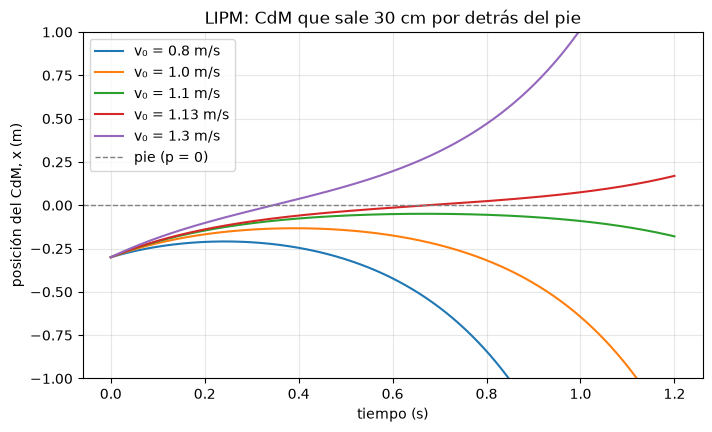

In [15]:
t = np.linspace(0.0, 1.2, 600)
fig, ax = plt.subplots(figsize=(8, 4.5))
for v0 in [0.8, 1.0, 1.1, 1.13, 1.3]:
    x, _ = lipm(-0.3, v0, 0.0, t)
    ax.plot(t, x, label=f"v₀ = {v0} m/s")
ax.axhline(0.0, color="gray", linestyle="--", linewidth=1, label="pie (p = 0)")
ax.set_xlabel("tiempo (s)")
ax.set_ylabel("posición del CdM, x (m)")
ax.set_title("LIPM: CdM que sale 30 cm por detrás del pie")
ax.set_ylim(-1.0, 1.0)
ax.grid(alpha=0.3)
ax.legend()
plt.show()

### Colores con significado: mapas de color

Con cinco curvas, los colores por defecto bastan. Pero si dibujas **cincuenta** (una por cada velocidad inicial), la leyenda sería ilegible. La solución profesional: que el **color** signifique el número. Un **mapa de color** (*colormap*) traduce un número a un color, y una **barra de color** (*colorbar*) hace de leyenda.

De paso, un patrón muy importante: **las funciones que dibujan reciben el `ax`** donde dibujar, en vez de crear su propia figura. Así la misma función sirve para una gráfica sola o para una de las cuatro de una figura.


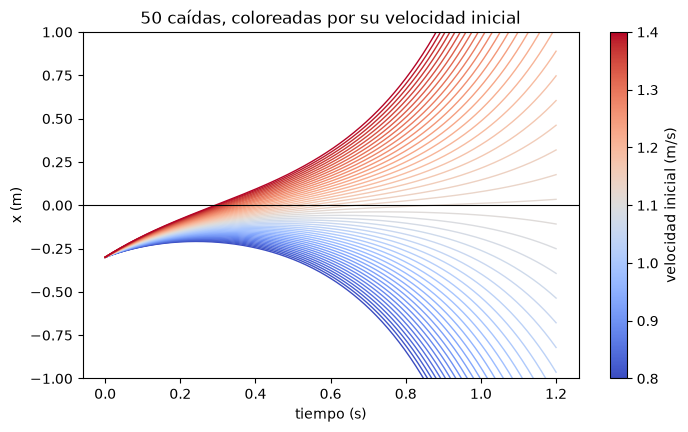

In [16]:
from matplotlib import cm
from matplotlib.colors import Normalize

def dibujar_familia(ax, velocidades, t, mapa="coolwarm"):
    '''Dibuja en ax una caída del LIPM por cada velocidad inicial, coloreada por su valor.'''
    normaliza = Normalize(vmin=velocidades.min(), vmax=velocidades.max())
    colores = plt.get_cmap(mapa)
    x, _ = lipm(-0.3, velocidades[:, np.newaxis], 0.0, t)
    for fila, v0 in zip(x, velocidades):
        ax.plot(t, fila, color=colores(normaliza(v0)), linewidth=1)
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.set_xlabel("tiempo (s)")
    ax.set_ylabel("x (m)")
    ax.set_ylim(-1.0, 1.0)
    return cm.ScalarMappable(norm=normaliza, cmap=colores)

fig, ax = plt.subplots(figsize=(8, 4.5))
escala = dibujar_familia(ax, np.linspace(0.8, 1.4, 50), np.linspace(0, 1.2, 400))
fig.colorbar(escala, ax=ax, label="velocidad inicial (m/s)")
ax.set_title("50 caídas, coloreadas por su velocidad inicial")
plt.show()

Las piezas:

- **`Normalize(vmin, vmax)`** convierte un valor en un número entre 0 y 1 (el mínimo → 0, el máximo → 1).
- **`plt.get_cmap("coolwarm")`** da un mapa de color: una función que convierte un número de 0 a 1 en un color (0 → azul, 0,5 → gris, 1 → rojo). Hay muchos; `"viridis"` es el clásico para valores que solo crecen, y uno de dos lados como `"coolwarm"` va bien cuando hay un **centro** con significado.
- **`cm.ScalarMappable`** junta las dos cosas en un objeto que `fig.colorbar` sabe dibujar como barra.
- Y la función **devuelve** ese objeto, para que quien la llama decida si pone barra o no. (Patrón de matplotlib: los métodos de dibujo devuelven los objetos que crean, por si quieres retocarlos.)

La gráfica cuenta la historia entera: las azules caen hacia atrás, las rojas hacia delante, y en medio hay una **frontera muy fina**, una sola velocidad que se queda en equilibrio sobre el pie. Es la velocidad justa del NB39. Ahora vamos a entender de dónde sale, con una idea nueva.


## 6 · Las dos mitades del movimiento: el DCM

### Lo que escondía A

Vuelve a la solución con exponenciales: u(t) = A · e^(ωt) + B · e^(−ωt). Los dos trozos se comportan de forma **opuesta**:

- El trozo de **B** lleva e^(−ωt), que **se apaga**: cada 1/ω segundos (unos 0,27 s en Zancudo) se divide entre 2,718. Medio segundo después, casi ha desaparecido.
- El trozo de **A** lleva e^(ωt), que **se dispara**: cada 0,27 s se multiplica por 2,718.

Así que, pase lo que pase al principio, **al cabo de un rato solo manda A**. Si A es positivo, el CdM acaba cayendo hacia delante; si es negativo, hacia atrás. Y si A es **exactamente cero**, solo queda el trozo que se apaga: el CdM se va acercando al pie y se para encima. ¡Equilibrio!

Recuerda: A = (u₀ + v₀/ω) / 2. Que A sea cero significa u₀ + v₀/ω = 0. Con u₀ = −0,3 (30 cm por detrás): v₀ = 0,3 · ω = **1,115 m/s**. Ahí está la velocidad justa de la gráfica: la frontera entre azules y rojas es **A = 0**.

### El componente divergente del movimiento

Esa combinación, la posición más la velocidad dividida entre ω, es tan importante que tiene nombre. La llamaremos **ξ** (la letra griega "xi", que se pronuncia "csi"):

```
ξ  =  x + v / ω
```

¿Te suena? En el NB39, el **punto de captura** era x + v/ω. **Es lo mismo.** En la literatura moderna se llama **DCM**, *divergent component of motion*, "componente divergente del movimiento" (porque "diverge", se aleja). Punto de captura y DCM son el mismo número con dos nombres; en artículos recientes casi siempre verás DCM.

Ahora la gran idea. Calculemos cómo cambia ξ con el tiempo. Su velocidad es la de x (que es v) más la de v dividida entre ω (que es aceleración/ω = ω²(x − p)/ω = ω(x − p)):

```
velocidad de ξ  =  v + ω · (x − p)  =  ω · (x + v/ω − p)  =  ω · (ξ − p)
```

Y la del CdM, despejando v de la definición de ξ (v = ω · (ξ − x)):

```
velocidad de x  =  −ω · (x − ξ)
```

Mira qué dos ecuaciones tan distintas:

1. **ξ huye del pie**: su velocidad es ω por la distancia al pie, **alejándose**. Cuanto más lejos, más deprisa se aleja. Es inestable: ξ(t) = p + (ξ₀ − p) · e^(ωt).
2. **x persigue a ξ**: su velocidad es ω por la distancia a ξ, **acercándose**. Es estable: si ξ se quedara quieto, x llegaría hasta él (como el amortiguador del NB39b).

Es decir: **el centro de masas no hace falta controlarlo; va solo detrás del DCM**. Lo único que hay que controlar es el DCM, y la única herramienta es **dónde está el pie** (p), que decide hacia dónde huye. Por eso los controladores modernos de robots bípedos (los de IHMC, los del TORO del DLR, muchos humanoides comerciales) controlan el DCM y no el CdM: es controlar **la mitad del problema que importa**.


Veámoslo en una caída. A la izquierda, el CdM y su DCM a lo largo del tiempo; a la derecha, el **retrato de fase**: cada caída como una curva en un plano con la **posición** (respecto al pie) en horizontal y la **velocidad** en vertical. (Es una forma muy útil de ver un sistema: cada punto del plano es un estado, y la curva es el camino que sigue.)

Para poner dos gráficas lado a lado, `plt.subplots(1, 2)` crea **una fila con dos `Axes`**, y nos los da en un array: `ejes[0]` y `ejes[1]`. Y `layout="constrained"` recoloca todo para que los títulos y etiquetas no se pisen (antes se usaba `plt.tight_layout()`).


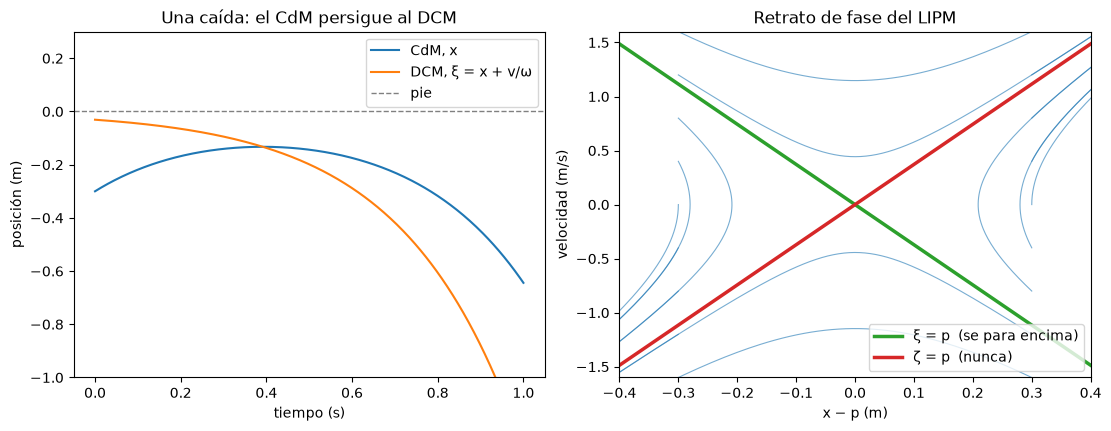

In [17]:
def dcm(x, v, w=omega):
    return x + v / w

fig, ejes = plt.subplots(1, 2, figsize=(11, 4.2), layout="constrained")

t = np.linspace(0.0, 1.0, 400)
x, v = lipm(-0.3, 1.0, 0.0, t)
ejes[0].plot(t, x, label="CdM, x")
ejes[0].plot(t, dcm(x, v), label="DCM, ξ = x + v/ω")
ejes[0].axhline(0.0, color="gray", linestyle="--", linewidth=1, label="pie")
ejes[0].set(xlabel="tiempo (s)", ylabel="posición (m)", title="Una caída: el CdM persigue al DCM", ylim=(-1.0, 0.3))
ejes[0].legend()

u = np.linspace(-0.4, 0.4, 2)
for u0 in [-0.3, 0.3]:
    for v0 in np.linspace(-1.6, 1.6, 9):
        x, v = lipm(u0, v0, 0.0, np.linspace(0.0, 1.5, 300))
        ejes[1].plot(x, v, color="tab:blue", linewidth=0.8, alpha=0.6)
ejes[1].plot(u, -omega * u, color="tab:green", linewidth=2.5, label="ξ = p  (se para encima)")
ejes[1].plot(u, omega * u, color="tab:red", linewidth=2.5, label="ζ = p  (nunca)")
ejes[1].set(xlabel="x − p (m)", ylabel="velocidad (m/s)", title="Retrato de fase del LIPM", xlim=(-0.4, 0.4), ylim=(-1.6, 1.6))
ejes[1].legend(loc="lower right")
plt.show()

(Un atajo nuevo: `ax.set(xlabel=..., ylabel=..., title=..., ylim=...)` pone varias cosas de golpe; equivale a llamar a `set_xlabel`, `set_ylabel`, etc. una por una.)

**Izquierda**: el DCM (naranja) arranca en −0,3 + 1/3,717 = −0,031 m, un poco por **detrás** del pie, y desde ahí huye hacia atrás, cada vez más deprisa. El CdM (azul) avanza al principio (lleva velocidad hacia delante), pero el DCM ya "sabe" que no va a llegar: el CdM acaba dándose la vuelta y persiguiéndolo hacia atrás.

**Derecha**: todas las caídas posibles. Las curvas azules son **hipérbolas** (como en el NB39, "órbitas") que vienen de lejos, se acercan al centro y se escapan. Hay dos rectas especiales:

- La **verde**, v = −ω · (x − p), es donde **ξ = p**: el DCM está justo sobre el pie. Las caídas que empiezan en ella **se deslizan por la recta hasta el centro**: el CdM llega al pie y se para. Es la "recta de captura".
- La **roja**, v = ω · (x − p), es donde la **otra** combinación, **ζ = x − v/ω** (la letra "zeta"), está sobre el pie. ζ es el **componente convergente** (nada que ver con la ζ del amortiguador del NB39b: en física se reutilizan mucho las letras griegas): su velocidad es −ω · (ζ − p), siempre **hacia** el pie. El CdM es justo la media de los dos: x = (ξ + ζ) / 2.

Todo sistema de este tipo (uno que se dispara en una dirección y se calma en otra) se llama un **punto de silla**, por la forma de la superficie de energía: como la silla de montar un caballo, que sube hacia delante y atrás y baja hacia los lados.

### La energía orbital, desvelada

En el NB39 vimos que la **energía orbital**, E = v² − ω²(x − p)², no cambia durante una caída. Ahora sabemos por qué. Es una diferencia de cuadrados, a² − b² = (a − b)(a + b):

```
E  =  (v − ω·u) · (v + ω·u)  =  (−ω·(ζ − p)) · (ω·(ξ − p))  =  −ω² · (ξ − p) · (ζ − p)
```

¡Es el **producto** de las dos mitades! Una crece como e^(ωt) y la otra mengua como e^(−ωt); multiplicadas, e^(ωt) · e^(−ωt) = e⁰ = 1: el producto no cambia. Comprobémoslo:


In [18]:
t = np.linspace(0.0, 1.0, 5)
x, v = lipm(-0.3, 1.0, 0.0, t)
xi, zeta = x + v / omega, x - v / omega
print("ξ − p:  ", xi)
print("ζ − p:  ", zeta)
print("E:      ", v ** 2 - omega ** 2 * x ** 2)
print("−ω²·ξ·ζ:", -omega ** 2 * xi * zeta)

ξ − p:   [-0.031  -0.0784 -0.1987 -0.5032 -1.2744]
ζ − p:   [-0.569  -0.2247 -0.0887 -0.035  -0.0138]
E:       [-0.2435 -0.2435 -0.2435 -0.2435 -0.2435]
−ω²·ξ·ζ: [-0.2435 -0.2435 -0.2435 -0.2435 -0.2435]


ξ se multiplica por más de 40 en un segundo (de −0,031 a −1,27), ζ se divide entre 40 (de −0,569 a −0,014), y su producto, la energía orbital, se queda clavado en **−0,2435**. Esta vez **exacto**, sin la pequeña deriva del NB39: aquella deriva era el error de Euler.

### Capturar = poner el pie en el DCM

Ahora la receta del punto de captura se entiende sola. Si pones el pie **exactamente en ξ**, el DCM deja de huir (su velocidad es ω · (ξ − p) = 0) y se queda quieto. Y el CdM, que lo persigue, llega hasta él. Con la fórmula de la persecución, x(t) = ξ + (x₀ − ξ) · e^(−ωt): la distancia se divide entre 2,718 cada 0,27 s.

El ejemplo del NB39: el robot, quieto con el CdM sobre el pie, recibe un empujón de 0,5 m/s:


In [19]:
x0, v0 = 0.0, 0.5
xi = dcm(x0, v0)
t_1mm = math.log(abs(x0 - xi) / 0.001) / omega
print(f"DCM: {xi:.4f} m   tarda {t_1mm:.2f} s en quedar a menos de 1 mm")
print("posición tras 3 s:", lipm(x0, v0, xi, 3.0))

DCM: 0.1345 m   tarda 1.32 s en quedar a menos de 1 mm
posición tras 3 s: (np.float64(0.13451119783439935), np.float64(7.178103260230273e-06))


El DCM está a **13,5 cm** (con la altura de Zancudo; en el NB39, con 0,8 m, eran 14,3). Pisando ahí, el CdM se queda a menos de 1 mm al cabo de **1,32 s**, y tras 3 s está prácticamente parado encima del pie. (Para despejar el tiempo usamos el **logaritmo neperiano**, `math.log`, del NB15b: la operación inversa de la exponencial. Si e^(ωt) = 134,5, entonces ωt = log(134,5). Igual que la raíz deshace el cuadrado.)

Un detalle fino: el CdM **nunca llega del todo**. La distancia se va dividiendo entre 2,718 sin llegar a cero, como en la paradoja de Aquiles y la tortuga. En la práctica, al cabo de un segundo y poco, la diferencia es menor que cualquier cosa medible.


## 7 · ¿Cuántos pasos necesitas para frenar?

En el NB39 dejamos una pregunta abierta: si el empujón es tan fuerte que el punto de captura queda más lejos de lo que alcanza la pierna, ¿qué pasa? Respuesta: hacen falta **varios pasos**. Es la idea de **capturabilidad con N pasos** (*N-step capturability*), de Koolen, Pratt y otros (2012), una pregunta clásica de entrevista.

Tres limitaciones de un robot de verdad:

- **r**: el pie no es un punto. El ZMP (NB39) puede estar en cualquier sitio de la planta, así que el robot puede "mover p" un poco **sin dar ningún paso**, con el tobillo. Para Zancudo, digamos que el ZMP puede ir hasta **r = 5 cm** por delante o por detrás del centro del pie.
- **L**: la pierna no llega infinitamente lejos. Paso máximo **L = 35 cm**.
- **Δt**: mover la pierna tarda. Como mínimo **Δt = 0,3 s** para levantarla, llevarla y apoyarla. Y durante ese tiempo, el DCM **sigue huyendo**.

Llamemos **d_N** a la distancia máxima entre el DCM y el pie con la que el robot puede pararse en N pasos:

- **0 pasos**: el DCM tiene que caer dentro del pie: d₀ = r.
- **N pasos**: durante el primer paso, el ZMP va al borde del pie (lo más cerca posible del DCM, para frenar su huida). El DCM, que estaba a d del pie, se aleja: al apoyar el pie nuevo, está a r + (d − r) · e^(ωΔt) del pie viejo. El pie nuevo cae como mucho a L, así que queda a r + (d − r) · e^(ωΔt) − L del pie nuevo... y eso tiene que ser como mucho d_(N−1) (lo que se puede arreglar con los pasos que quedan). Despejando:

```
d_N  =  r + (L + d_(N−1) − r) · e^(−ωΔt)
```

Una fórmula **recursiva**: cada d se calcula con el anterior (como la cadena del NB07). Calculémoslos, y traduzcamos cada distancia al **empujón máximo** que se aguanta (si el CdM está sobre el pie, el DCM está a v/ω, así que el empujón máximo es v = ω · d_N):


In [20]:
r, L, dt_paso = 0.05, 0.35, 0.3
encoge = math.exp(-omega * dt_paso)
print(f"e^(−ωΔt) = {encoge:.3f}")

d = [r]
for n in range(1, 7):
    d.append(r + (L + d[-1] - r) * encoge)
d = np.array(d)
for n, dn in enumerate(d):
    print(f"{n} pasos: DCM a menos de {dn * 100:5.1f} cm  →  empujón de hasta {omega * dn:.2f} m/s")
print(f"límite con infinitos pasos: {(r + L * encoge / (1 - encoge)) * 100:.1f} cm")

e^(−ωΔt) = 0.328
0 pasos: DCM a menos de   5.0 cm  →  empujón de hasta 0.19 m/s
1 pasos: DCM a menos de  16.5 cm  →  empujón de hasta 0.61 m/s
2 pasos: DCM a menos de  20.2 cm  →  empujón de hasta 0.75 m/s
3 pasos: DCM a menos de  21.5 cm  →  empujón de hasta 0.80 m/s
4 pasos: DCM a menos de  21.9 cm  →  empujón de hasta 0.81 m/s
5 pasos: DCM a menos de  22.0 cm  →  empujón de hasta 0.82 m/s
6 pasos: DCM a menos de  22.1 cm  →  empujón de hasta 0.82 m/s
límite con infinitos pasos: 22.1 cm


Las cifras cuentan algo importante:

- **Sin pasos**, solo con el tobillo, Zancudo aguanta empujones de **0,19 m/s**: poquísimo.
- **Un paso** lo multiplica por tres: hasta **0,61 m/s**.
- **Dos**, 0,75; **tres**, 0,80... y a partir de ahí, casi nada más. Con infinitos pasos, el límite es **22,1 cm** (0,82 m/s).

¿Por qué se satura? Por el e^(−ωΔt) = 0,328: cada paso extra ayuda **un tercio** de lo que ayudó el anterior. Mientras mueves la pierna, el DCM se va escapando; un paso tardío vale poco. Un empujón de más de 0,82 m/s **no se puede parar**, dé los pasos que dé (con estos límites).

Y una lección para el diseño: ¿qué ayuda más, piernas más largas o piernas más rápidas? El ejercicio E3 lo responde con números.

Dibujémoslo con un **diagrama de barras** (`ax.bar`) y, de paso, otra herramienta de informe: **`ax.annotate`**, que escribe un texto con una flecha apuntando a un sitio.


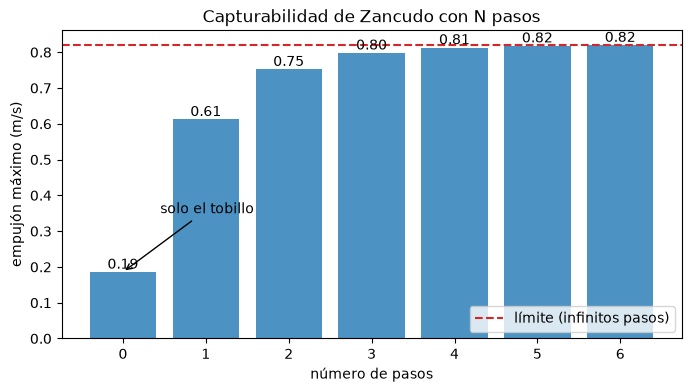

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
barras = ax.bar(np.arange(len(d)), omega * d, color="tab:blue", alpha=0.8)
ax.bar_label(barras, fmt="%.2f")
ax.axhline(omega * (r + L * encoge / (1 - encoge)), color="tab:red", linestyle="--", label="límite (infinitos pasos)")
ax.annotate("solo el tobillo", xy=(0, omega * r), xytext=(0.45, 0.35),
            arrowprops=dict(arrowstyle="->"))
ax.set(xlabel="número de pasos", ylabel="empujón máximo (m/s)", title="Capturabilidad de Zancudo con N pasos")
ax.legend(loc="lower right")
plt.show()

(`ax.bar_label` escribe el valor encima de cada barra; `fmt="%.2f"` es el formato con dos decimales, el "viejo" estilo de Python para formatear, equivalente a `{:.2f}`. Y en `annotate`, `xy` es el punto al que apunta la flecha y `xytext` dónde va el texto.)


## 8 · Andar a ritmo constante

Hasta aquí, **parar**. Ahora, **andar**. Empecemos por el caso más sencillo: un robot que ya va lanzado, con pasos todos iguales de longitud **s**, cada uno de **T** segundos. El movimiento del CdM se repite igual en cada paso: es una **marcha periódica**.

Por simetría, en cada paso el CdM entra **s/2 por detrás** del pie de apoyo, pasa por encima, y sale **s/2 por delante**, justo cuando se apoya el pie siguiente (que está s más allá, así que el CdM vuelve a estar s/2 por detrás del nuevo pie). Y sale con **la misma velocidad** con la que entró. Con la solución del LIPM y un poco de álgebra (la tienes en el E4), la velocidad al cambiar de pie tiene que ser:

```
v₀  =  ω · (s/2) / tanh(ωT/2)          con   tanh = sinh / cosh   ("tangente hiperbólica")
```

Comprobémoslo con un paso de 30 cm en 0,4 s:


In [22]:
def velocidad_periodica(s, T, w=omega):
    return w * (s / 2) / np.tanh(w * T / 2)

s, T = 0.3, 0.4
v0 = velocidad_periodica(s, T)
x_fin, v_fin = lipm(-s / 2, v0, 0.0, T)
print(f"v₀ = {v0:.3f} m/s   →   al final del paso: x = {x_fin:.4f} m, v = {v_fin:.3f} m/s")
print(f"velocidad media: {s / T:.2f} m/s   velocidad mínima (encima del pie): {lipm(-s / 2, v0, 0.0, T / 2)[1]:.3f} m/s")

v₀ = 0.883 m/s   →   al final del paso: x = 0.1500 m, v = 0.883 m/s
velocidad media: 0.75 m/s   velocidad mínima (encima del pie): 0.685 m/s


El CdM sale en **+0,15 m** (s/2) con la **misma** velocidad, 0,883 m/s: el paso siguiente es idéntico. La velocidad media es 0,75 m/s, pero el CdM no va a velocidad constante: se **frena** al subir hacia el pie (0,685 m/s justo encima) y se **acelera** al caer delante. Por eso al andar notas un pequeño vaivén hacia delante y atrás.

### Una tabla entera con broadcasting

¿Y para todas las combinaciones de longitud y duración del paso? Con **`np.meshgrid`**, que fabrica dos tablas a partir de dos listas: una con la s de cada casilla y otra con la T. Y como `velocidad_periodica` está vectorizada, una sola llamada calcula todas las casillas. Para dibujar una tabla así con colores se usa **`ax.pcolormesh`**, y **`ax.contour`** añade líneas de nivel con su valor:


forma de S y TT: (51, 61)


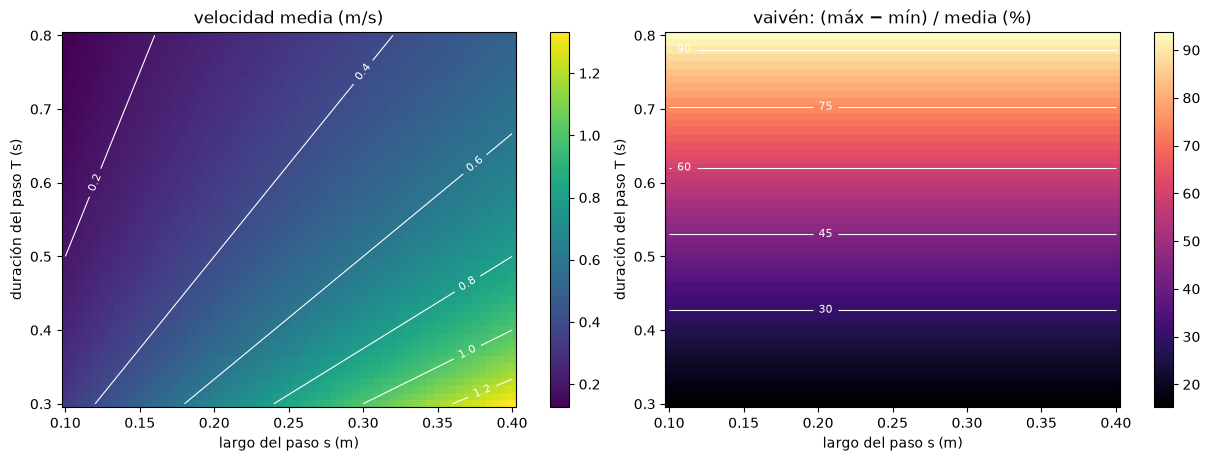

In [23]:
largos = np.linspace(0.1, 0.4, 61)
duraciones = np.linspace(0.3, 0.8, 51)
S, TT = np.meshgrid(largos, duraciones)
print("forma de S y TT:", S.shape)

V0 = velocidad_periodica(S, TT)
media = S / TT
vaiven = (V0 - lipm(-S / 2, V0, 0.0, TT / 2)[1]) / media

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
for ax, tabla, titulo, mapa in [(ejes[0], media, "velocidad media (m/s)", "viridis"),
                                 (ejes[1], 100 * vaiven, "vaivén: (máx − mín) / media (%)", "magma")]:
    malla = ax.pcolormesh(S, TT, tabla, cmap=mapa, shading="auto")
    lineas = ax.contour(S, TT, tabla, colors="white", linewidths=0.8, levels=6)
    ax.clabel(lineas, fontsize=8)
    fig.colorbar(malla, ax=ax)
    ax.set(xlabel="largo del paso s (m)", ylabel="duración del paso T (s)", title=titulo)
plt.show()

(`np.meshgrid(largos, duraciones)` da dos tablas de 51 filas, una por duración, y 61 columnas, una por largo. `shading="auto"` le dice a `pcolormesh` cómo colocar las casillas; `ax.clabel` escribe los valores sobre las líneas de nivel.)

- **Izquierda**: la velocidad media es simplemente s/T. Para ir más deprisa, pasos más largos o más rápidos.
- **Derecha**, lo interesante: el **vaivén** de la velocidad, en porcentaje de la media. ¡Sorpresa: las franjas son **horizontales**! El vaivén **no depende del largo** del paso, solo de su **duración**. (Tiene sentido mirando las fórmulas: v₀, la velocidad mínima y la media son todas proporcionales a s, así que al dividir, s se va.) Con pasos de 0,3 s el vaivén es de un 15 %; con 0,5 s, de un 40 %; con 0,8 s, ¡más del 90 %!: el CdM casi se para encima de cada pie y luego se lanza.

Por eso andar con pasos lentos se ve tan torpe, y por eso los robots (y las personas) que van deprisa **aumentan la frecuencia de paso**, y no solo la longitud. Y por eso los primeros humanoides, que andaban con pasos lentos, se veían tan "robóticos".


## 9 · Un plan de pasos: dónde pisar

Ahora, un trayecto de verdad: Zancudo empieza **quieto**, con los dos pies juntos, anda **1 metro** y se **para**, otra vez con los pies juntos. Y lo planificamos en **2D**, mirado desde arriba: el pie derecho está 10 cm a la derecha del centro y el izquierdo 10 cm a la izquierda (la anchura de cadera de Zancudo es 0,2 m, NB42). Zancudo de verdad solo se mueve en un plano (no puede caerse hacia los lados), pero el plan lo hacemos ya completo, en 2D, porque en el NB53 Zancudo pasará a 3D y lo necesitará.

Usaremos el eje **x** hacia delante y el eje **y** hacia la izquierda (el convenio de MuJoCo y de ROS: x delante, y izquierda, z arriba).

La lista de pisadas es una tabla de N filas y 2 columnas (x, y), y la fabricamos con NumPy, sin bucles:

1. Las posiciones x: 0, s, 2s, 3s... sin pasarse de la distancia (`np.minimum`).
2. Al final, un pie más **a la misma altura** que el último, para acabar con los pies juntos.
3. Las y, alternando derecha, izquierda, derecha... con `np.where` sobre "¿la posición es par?" (`% 2 == 0`, el resto de dividir entre 2, P1).
4. `np.column_stack` pega las dos columnas en una tabla.


In [24]:
def plan_pies(distancia: float, largo: float, ancho: float) -> NDArray[np.float64]:
    '''Pisadas (x, y) para andar `distancia` m con pasos de `largo` m. Empieza en el pie derecho.'''
    n = math.ceil(distancia / largo)
    xs = np.minimum(np.arange(1, n + 1) * largo, distancia)
    xs = np.concatenate([[0.0], xs, [distancia]])
    ys = np.where(np.arange(len(xs)) % 2 == 0, -ancho / 2, ancho / 2)
    return np.column_stack([xs, ys])

ANCHO = 0.2
pies = plan_pies(1.0, 0.25, ANCHO)
print(pies)

[[ 0.   -0.1 ]
 [ 0.25  0.1 ]
 [ 0.5  -0.1 ]
 [ 0.75  0.1 ]
 [ 1.   -0.1 ]
 [ 1.    0.1 ]]


Seis pisadas. La primera, (0, −0,1), es el pie derecho **donde ya está**: es el pie de apoyo del primer paso. Luego, el izquierdo avanza a 0,25; el derecho, a 0,5; el izquierdo, a 0,75; el derecho, a 1,0; y el izquierdo se pone a su lado, en (1,0, 0,1).

Para dibujar los pies como **rectángulos** se usan los ***patches*** de matplotlib (`matplotlib.patches`): formas geométricas (rectángulos, círculos, flechas...) que se añaden a un `Axes` con `ax.add_patch`. Y en una vista desde arriba es **imprescindible** `ax.set_aspect("equal")`: que 1 cm en x mida lo mismo en pantalla que 1 cm en y. Si no, los pies saldrían deformados y las distancias engañarían.


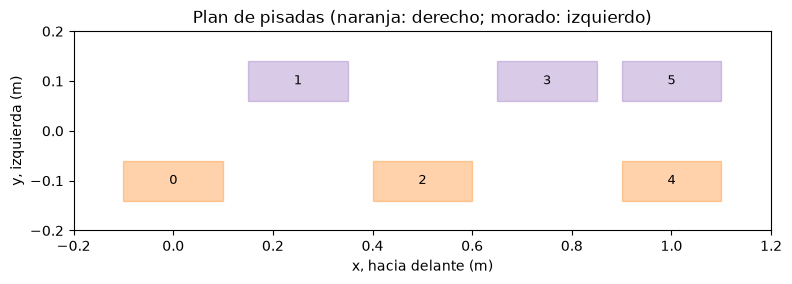

In [25]:
from matplotlib.patches import Rectangle

LARGO_PIE, ANCHO_PIE = 0.2, 0.08

def dibujar_pies(ax, pies, **estilo):
    '''Dibuja cada pisada como un rectángulo centrado en ella, y numera el orden.'''
    for k, (x, y) in enumerate(pies):
        color = "tab:orange" if y < 0 else "tab:purple"
        ax.add_patch(Rectangle((x - LARGO_PIE / 2, y - ANCHO_PIE / 2), LARGO_PIE, ANCHO_PIE,
                               facecolor=color, alpha=0.35, edgecolor=color, **estilo))
        ax.text(x, y, str(k), ha="center", va="center", fontsize=9)

fig, ax = plt.subplots(figsize=(9, 3))
dibujar_pies(ax, pies)
ax.set_aspect("equal")
ax.set(xlim=(-0.2, 1.2), ylim=(-0.2, 0.2), xlabel="x, hacia delante (m)", ylabel="y, izquierda (m)",
       title="Plan de pisadas (naranja: derecho; morado: izquierdo)")
plt.show()

(`Rectangle` recibe la **esquina** de abajo a la izquierda, el ancho y el alto; por eso restamos la mitad del largo y del ancho. `**estilo` recoge los argumentos con nombre que quiera pasar quien llama, como `linewidth=2`, y los reenvía al rectángulo: el desempaquetado de diccionarios del P2. Y `ha`/`va` en `ax.text` centran el texto, horizontal y verticalmente.)

Las pisadas son la mitad del plan: el **dónde**. Falta el **cuándo**: cada paso dura **T = 0,5 s**. Y falta lo más difícil: por dónde tiene que ir el centro de masas para que todo esto no acabe en el suelo.


## 10 · El plan del DCM: de atrás hacia delante

### La idea

Mientras el pie k está apoyado, en 2D el DCM sigue la misma ley de antes, en x y en y a la vez: huye del pie, ξ(t) = p_k + (ξ_inicio − p_k) · e^(ωt). Al cabo de T segundos, se apoya el pie siguiente, y el DCM empieza a huir de **ese**.

Problema: ¿dónde tiene que estar el DCM al empezar cada paso? Si lo planificamos **hacia delante** (empezando quietos y simulando), cualquier pequeño desajuste crece paso a paso, y al final no acabaríamos parados donde queremos.

El truco (de Englsberger, Ott y Albu-Schäffer, del DLR alemán, 2011-2015): planificarlo **hacia atrás**. Porque sabemos muy bien cómo tiene que **acabar**: parado, con el DCM en el centro de los dos pies (el punto medio de las dos últimas pisadas). Y la ley del DCM se puede "dar la vuelta": si al final del paso k tiene que estar en ξ_fin, al principio tenía que estar en

```
ξ_inicio  =  p_k + (ξ_fin − p_k) · e^(−ωT)
```

(Es la ley de la huida despejada: si en T segundos la distancia al pie se multiplica por e^(ωT), al principio era la de ahora dividida entre e^(ωT).) Y el principio de un paso es el final del anterior. Así que se empieza por el último paso y se va hacia atrás, paso a paso, hasta el primero.

Fíjate en la belleza: **hacia atrás, la parte inestable se vuelve estable** (los errores se encogen multiplicando por e^(−ωT) = 0,156, en vez de crecer). Es una idea que aparece mucho en control: lo que diverge hacia el futuro converge hacia el pasado.


In [26]:
T = 0.5
apoyos = pies[:-1]
final = (pies[-1] + pies[-2]) / 2
print("pies de apoyo:", len(apoyos), "  DCM final (centro de los dos últimos pies):", final)

xi_ini = np.empty_like(apoyos)
xi_fin = np.empty_like(apoyos)
siguiente = final
for k in range(len(apoyos) - 1, -1, -1):
    xi_fin[k] = siguiente
    xi_ini[k] = apoyos[k] + (xi_fin[k] - apoyos[k]) * math.exp(-omega * T)
    siguiente = xi_ini[k]

print("DCM al empezar cada paso:")
print(xi_ini)

pies de apoyo: 5   DCM final (centro de los dos últimos pies): [1. 0.]
DCM al empezar cada paso:
[[ 0.0461 -0.073 ]
 [ 0.296   0.073 ]
 [ 0.5451 -0.0733]
 [ 0.789   0.0713]
 [ 1.     -0.0844]]


(Los **pies de apoyo** son todas las pisadas **menos la última**: la última solo se apoya para juntar los pies, ya no se "anda" sobre ella. `np.empty_like(apoyos)` crea un array de la misma forma sin rellenar, porque lo vamos a llenar entero. Y `range(len(apoyos) - 1, -1, -1)` cuenta **hacia atrás**: 4, 3, 2, 1, 0; el tercer número de `range` es el salto, P1.)

Mira el patrón: el DCM empieza cada paso un poco **por delante** del pie de apoyo (0,046 m por delante del pie en x = 0; 0,046 por delante del de 0,25...) y **hacia dentro** (en y, unos 7,3 cm hacia el centro, no los 10 del pie). Durante el paso, huye del pie: hacia delante (para avanzar) y hacia el otro lado (para pasarse al otro pie). Justo lo que hace tu cuerpo al andar.

### El arranque

Un detalle: el plan quiere que, al empezar el primer paso, el DCM esté en (0,046, −0,073). Pero Zancudo está **quieto**, con el DCM en (0, 0), el centro de los pies. Hace falta una **fase de arranque**, con los dos pies en el suelo, para llevar el DCM hasta ahí.

Durante esa fase, el ZMP (el "p") puede estar en cualquier punto **entre los dos pies** (NB39). ¿Dónde lo ponemos para que el DCM llegue al sitio justo en T₀ = 0,5 s? Despejando de la ley de la huida, ξ_objetivo = p + (0 − p) · e^(ωT₀):


In [27]:
T0 = 0.5
zmp_arranque = -xi_ini[0] / (math.exp(omega * T0) - 1)
print("ZMP durante el arranque:", zmp_arranque)

ZMP durante el arranque: [-0.0085  0.0135]


(−0,009, +0,013): un poco hacia **atrás** y hacia la **izquierda**. Es el movimiento que haces sin darte cuenta antes de echar a andar: empujas el suelo un poquito hacia atrás y hacia el pie **izquierdo** para que tu cuerpo arranque hacia delante y hacia el **derecho**, que es el que se va a quedar apoyado. (Y está dentro del rectángulo que forman los dos pies: el plan es posible.)

### Del DCM al centro de masas

Ya sabemos dónde está el DCM en cada instante. ¿Y el CdM? Recuerda: el CdM **persigue** al DCM, con velocidad −ω · (x − ξ). Cuando ξ es la exponencial de un paso, ξ(t) = p + c · e^(ωt) (llamando c = ξ_inicio − p), esa persecución también tiene solución exacta:

```
x(t)  =  p + (c/2) · e^(ωt) + (x₀ − p − c/2) · e^(−ωt)
```

No hace falta creérselo: comprobemos con pendientes numéricas que cumple "velocidad = −ω · (x − ξ)" (con unos números cualesquiera):


In [28]:
p_, c_, x0_ = 0.25, 0.04, 0.12
def x_persigue(t):
    return p_ + c_ / 2 * np.exp(omega * t) + (x0_ - p_ - c_ / 2) * np.exp(-omega * t)
def xi_huye(t):
    return p_ + c_ * np.exp(omega * t)

t, h = 0.3, 1e-6
pendiente = (x_persigue(t + h) - x_persigue(t)) / h
print(round(pendiente, 5), "frente a", round(-omega * (x_persigue(t) - xi_huye(t)), 5))

0.40955 frente a 0.40955


Coinciden. Con todo esto, ya podemos construir el plan entero, fase a fase. Es un buen momento para organizar el código como un profesional:

- Una **`dataclass` congelada** (`frozen=True`, P3) para describir una **fase**: dónde está el ZMP, cuánto dura y dónde empieza el DCM. "Congelada" significa que no se puede modificar después de crearla: una fase del plan es un **dato**, no algo que vaya cambiando.
- Una función que, a partir de la lista de fases, calcula **todas** las trayectorias. Por dentro: un bucle **sobre las fases** (son 7) y, dentro de cada fase, **todo vectorizado** (cientos de instantes de golpe). Esa es la regla práctica: *bucle sobre pocas cosas, vector sobre muchas*.


In [29]:
from dataclasses import dataclass

@dataclass(frozen=True)
class Fase:
    zmp: NDArray[np.float64]        # dónde empuja el suelo (x, y)
    duracion: float                 # segundos
    xi_inicio: NDArray[np.float64]  # DCM al empezar la fase

fases = ([Fase(zmp_arranque, T0, np.zeros(2))]
         + [Fase(apoyos[k], T, xi_ini[k]) for k in range(len(apoyos))]
         + [Fase(final, 1.0, final)])
for f in fases:
    print(f"ZMP {f.zmp}   dura {f.duracion} s")

ZMP [-0.0085  0.0135]   dura 0.5 s
ZMP [ 0.  -0.1]   dura 0.5 s
ZMP [0.25 0.1 ]   dura 0.5 s
ZMP [ 0.5 -0.1]   dura 0.5 s
ZMP [0.75 0.1 ]   dura 0.5 s
ZMP [ 1.  -0.1]   dura 0.5 s
ZMP [1. 0.]   dura 1.0 s


Siete fases: arranque, cinco pasos y una fase final de un segundo con los pies juntos, el ZMP y el DCM en el centro (el DCM no huye porque está justo sobre el ZMP: el CdM simplemente se acaba de acercar).


In [30]:
def trayectoria_cdm(fases: list[Fase], paso: float = 0.001):
    '''Devuelve t, CdM, DCM y ZMP (cada uno, una tabla de n × 2) para la lista de fases.'''
    trozos_t, trozos_x, trozos_xi, trozos_zmp = [], [], [], []
    x = np.zeros(2)                       # el CdM empieza quieto en el origen
    inicio = 0.0
    for f in fases:
        t = np.arange(0.0, f.duracion, paso)[:, np.newaxis]     # columna: (n, 1)
        c = f.xi_inicio - f.zmp
        crece, mengua = np.exp(omega * t), np.exp(-omega * t)
        trozos_x.append(f.zmp + c / 2 * crece + (x - f.zmp - c / 2) * mengua)
        trozos_xi.append(f.zmp + c * crece)
        trozos_zmp.append(np.broadcast_to(f.zmp, (len(t), 2)))
        trozos_t.append(inicio + t[:, 0])
        T_ = f.duracion
        x = f.zmp + c / 2 * math.exp(omega * T_) + (x - f.zmp - c / 2) * math.exp(-omega * T_)
        inicio += T_
    return (np.concatenate(trozos_t), np.concatenate(trozos_x),
            np.concatenate(trozos_xi), np.concatenate(trozos_zmp))

t, X, XI, ZMP = trayectoria_cdm(fases)
print("instantes:", t.shape, "  CdM:", X.shape)
print("CdM al final:", X[-1], "  DCM al final:", XI[-1])

instantes: (4000,)   CdM: (4000, 2)
CdM al final: [ 0.9994 -0.0009]   DCM al final: [1. 0.]


El broadcasting trabaja en cada fase: `t` es una **columna** de n instantes (forma `(n, 1)`) y `c` o `f.zmp` son **filas** de 2 números (x, y); al operar, sale una tabla `(n, 2)`: x e y de cada instante, de una vez. `np.broadcast_to(f.zmp, (n, 2))` "estira" el ZMP a n filas **sin copiar** memoria (es una **vista** de solo lectura, P6). Y `np.concatenate` pega los trozos de todas las fases.

El CdM acaba en (0,9994, −0,0009): a menos de 1 mm de (1, 0), el centro de los pies finales, y acercándose (le hemos dado solo 1 s de fase final). El DCM, exactamente en (1, 0).

Ahora la figura del plan. Para una composición con una gráfica **grande** arriba y dos **pequeñas** debajo, matplotlib tiene **`plt.subplot_mosaic`**: describes la disposición con una lista de filas, poniendo un nombre en cada casilla (repetir un nombre hace que esa gráfica ocupe varias casillas), y te devuelve un **diccionario** de `Axes` por nombre. Mucho más legible que contar filas y columnas:


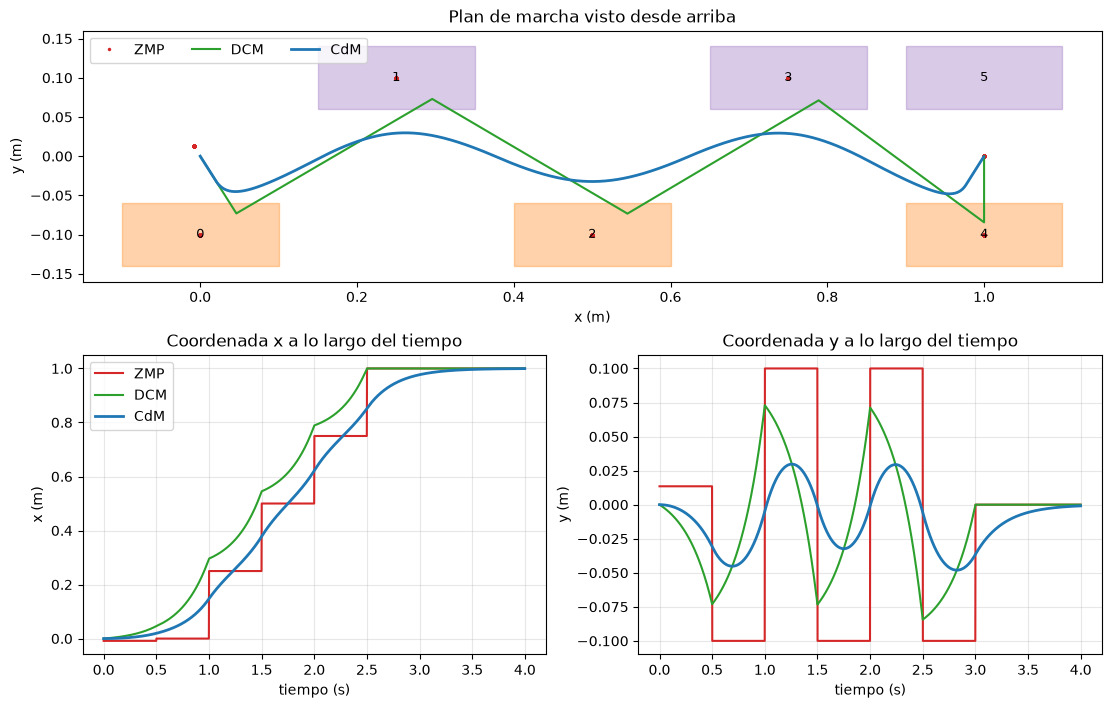

In [31]:
fig, ejes = plt.subplot_mosaic([["planta", "planta"],
                                 ["x", "y"]],
                                figsize=(11, 7), layout="constrained")

ax = ejes["planta"]
dibujar_pies(ax, pies)
ax.plot(ZMP[:, 0], ZMP[:, 1], ".", color="tab:red", markersize=3, label="ZMP")
ax.plot(XI[:, 0], XI[:, 1], color="tab:green", label="DCM")
ax.plot(X[:, 0], X[:, 1], color="tab:blue", linewidth=2, label="CdM")
ax.set_aspect("equal")
ax.set(xlim=(-0.15, 1.15), ylim=(-0.16, 0.16), xlabel="x (m)", ylabel="y (m)", title="Plan de marcha visto desde arriba")
ax.legend(loc="upper left", ncols=3)

for nombre, columna in [("x", 0), ("y", 1)]:
    ax = ejes[nombre]
    ax.plot(t, ZMP[:, columna], color="tab:red", label="ZMP")
    ax.plot(t, XI[:, columna], color="tab:green", label="DCM")
    ax.plot(t, X[:, columna], color="tab:blue", linewidth=2, label="CdM")
    ax.set(xlabel="tiempo (s)", ylabel=f"{nombre} (m)", title=f"Coordenada {nombre} a lo largo del tiempo")
    ax.grid(alpha=0.3)
ejes["x"].legend()

fig.savefig("assets/nb51_plan_de_marcha.png", dpi=150)
plt.show()

(`ncols=3` pone la leyenda en tres columnas. Y la última línea **guarda** la figura en un fichero antes de mostrarla: `fig.savefig(ruta, dpi=150)`. Los **dpi** (*dots per inch*, puntos por pulgada) deciden la resolución: 72-100 para pantalla, 150-300 para un informe o un artículo. La extensión elige el formato: `.png` para imágenes; `.pdf` o `.svg` para gráficos **vectoriales**, que no se pixelan nunca al ampliarlos, los que se usan en artículos. Así se fabrican las figuras de un portafolio.)

Lee la figura despacio, porque es **la** figura de la locomoción clásica:

- **Arriba**: el CdM (azul) avanza **culebreando**: se balancea hacia el pie de apoyo de cada momento, pero **sin llegar a ponerse encima**: unos 3 cm a cada lado a mitad de marcha (casi 5 en el primer y el último paso), cuando los pies están a 10. El DCM (verde) va siempre **por delante** y más "exagerado", y se mueve en **líneas rectas**: huye de cada pie en línea recta, alejándose de él (su velocidad, ω · (ξ − p), apunta siempre en la dirección pie → DCM). El ZMP (rojo) salta de pie en pie.
- **Abajo a la izquierda**: en x, el ZMP es una **escalera** (cada escalón, un pie). El DCM, en cada escalón, se aleja por encima: las curvitas exponenciales. El CdM, suave, va detrás.
- **Abajo a la derecha**: en y, el ZMP salta de −0,1 a +0,1 y vuelta; el DCM y el CdM ondulan entre los dos, con menos amplitud.

### Comprobaciones de ingeniero

Un plan bonito no basta: hay que **comprobar** que es posible. Tres preguntas, tres líneas de NumPy:


In [32]:
velocidad = np.gradient(X, t, axis=0)
print("1) ¿DCM = CdM + velocidad/ω?  error máximo:", np.abs(X + velocidad / omega - XI)[1:-1].max().round(5), "m")
print("2) velocidad máxima hacia delante:", velocidad[:, 0].max().round(3), "m/s   balanceo lateral máximo:", np.abs(X[:, 1]).max().round(3), "m")
alcance = np.linalg.norm(X - ZMP, axis=1).max()
print(f"3) distancia horizontal máxima CdM-pie: {alcance:.3f} m   (la pierna llega hasta {math.sqrt(0.8 ** 2 - 0.70 ** 2):.3f})")

1) ¿DCM = CdM + velocidad/ω?  error máximo: 0.00023 m
2) velocidad máxima hacia delante: 0.62 m/s   balanceo lateral máximo: 0.048 m
3) distancia horizontal máxima CdM-pie: 0.175 m   (la pierna llega hasta 0.387)


1. **El DCM cuadra**: calculado a partir del CdM y su velocidad (con `np.gradient`, que estima pendientes de datos, P6), coincide con el planificado: 0,2 mm de error, que es lo que se equivoca la propia pendiente numérica en los saltos entre fases.
2. **Velocidades razonables**: 0,62 m/s hacia delante como mucho, y un balanceo lateral de 4,8 cm.
3. **La pierna llega**: el CdM se separa del pie como mucho 17,5 cm en horizontal. La pierna de Zancudo mide 0,8 m (muslo + pierna) y la cadera va a unos 0,70 m sobre el tobillo, así que alcanza hasta √(0,8² − 0,7²) = 0,387 m. Sobra margen.

(`np.linalg.norm(..., axis=1)` calcula la **longitud** de cada fila, √(x² + y²), P7: la distancia de cada instante.)


## 11 · El pie en el aire

El plan dice dónde **pisa** cada pie. Pero mientras un pie está apoyado, el otro **viaja por el aire** de su pisada anterior a la siguiente. ¿Por qué camino? Parece un detalle, pero un camino malo hace que el pie llegue al suelo **de golpe** (un impacto que desequilibra y rompe piezas), que tropiece, o que los motores tengan que hacer fuerzas imposibles.

### Lo que pedimos a una trayectoria de pie

Usemos un "reloj" del paso, **σ** (sigma) = t / T, que va de 0 (despega) a 1 (aterriza). Queremos:

1. **Posición**: que empiece en la pisada vieja y acabe en la nueva.
2. **Velocidad cero** al despegar y al aterrizar: que el pie no **arrastre** ni **golpee**.
3. Mejor aún, **aceleración cero** en los extremos: que la fuerza de los motores no dé saltos (un salto de aceleración es un salto de fuerza: un "tirón").
4. **Altura** suficiente a mitad de camino para no tropezar, y **cero** en los extremos.

### Horizontal: tres perfiles

Para ir del 0 al 1 (luego se escala a la distancia real), tres candidatos:

- **Lineal**: f(σ) = σ. Velocidad constante... que salta de 0 a algo al despegar: un golpe.
- **Cúbico** (*smoothstep*): f(σ) = 3σ² − 2σ³. Velocidad cero en los extremos.
- **Quíntico**: f(σ) = 10σ³ − 15σ⁴ + 6σ⁵. Velocidad **y aceleración** cero en los extremos.

(Los números raros salen de imponer esas condiciones a un polinomio, como ajustamos A y B en el apartado 3; el E5 te pide comprobarlo.)

### Vertical: un bulto

Para la altura, que sube y baja:

- **Seno**: h · sin(πσ). Sube y baja suave... pero su velocidad **no es cero** en los extremos: el pie llega al suelo bajando.
- **Polinomio**: h · 64 · σ³ · (1 − σ)³. Cero en los extremos, con velocidad y aceleración cero; y en σ = 0,5 vale h · 64 · (1/8) · (1/8) = h.


   lineal: velocidad al despegar   1.00 | al aterrizar   1.00 | aceleración al aterrizar    0.00
   cúbico: velocidad al despegar   0.00 | al aterrizar   0.00 | aceleración al aterrizar   -5.99
 quíntico: velocidad al despegar  -0.00 | al aterrizar  -0.00 | aceleración al aterrizar   -0.04
     seno: velocidad al despegar   3.14 | al aterrizar  -3.14 | aceleración al aterrizar   -0.02
polinomio: velocidad al despegar  -0.00 | al aterrizar   0.00 | aceleración al aterrizar    0.29


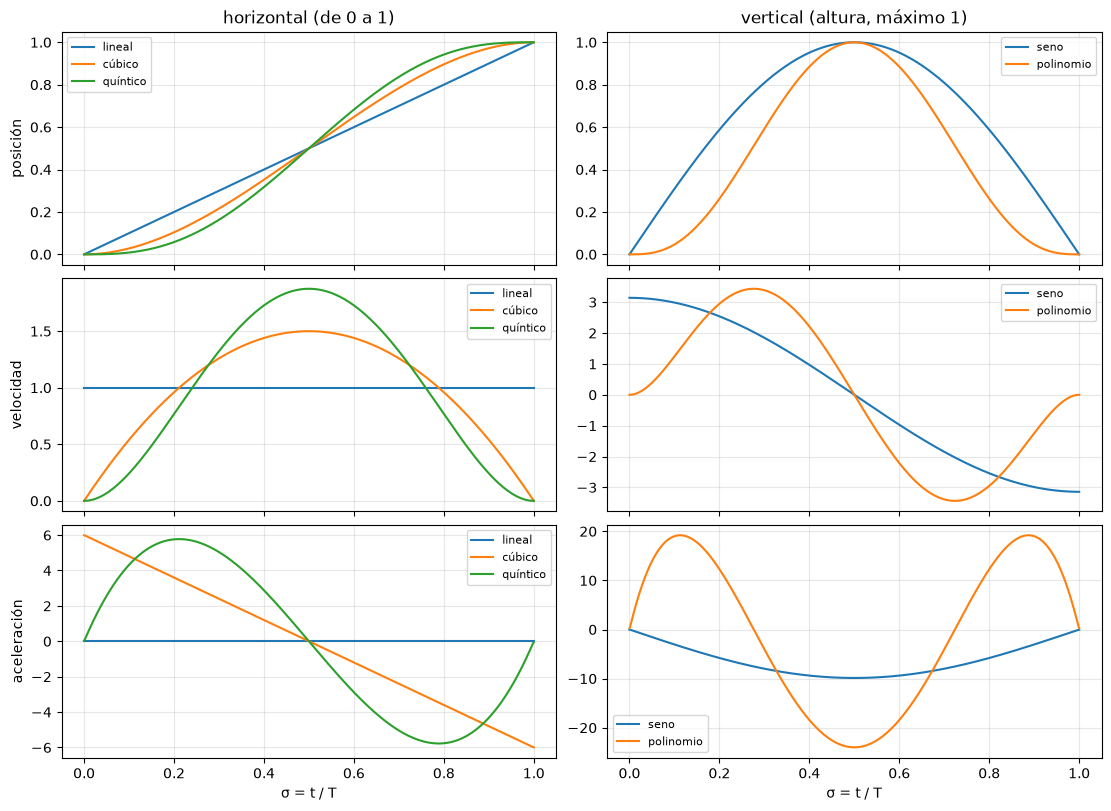

In [33]:
perfiles_x = {
    "lineal": lambda s: s,
    "cúbico": lambda s: 3 * s ** 2 - 2 * s ** 3,
    "quíntico": lambda s: 10 * s ** 3 - 15 * s ** 4 + 6 * s ** 5,
}
perfiles_z = {
    "seno": lambda s: np.sin(np.pi * s),
    "polinomio": lambda s: 64 * s ** 3 * (1 - s) ** 3,
}

sigma = np.linspace(0.0, 1.0, 1001)
fig, ejes = plt.subplots(3, 2, figsize=(11, 8), sharex=True, layout="constrained")
for columna, perfiles in enumerate([perfiles_x, perfiles_z]):
    for nombre, f in perfiles.items():
        posicion = f(sigma)
        velocidad = np.gradient(posicion, sigma, edge_order=2)
        aceleracion = np.gradient(velocidad, sigma, edge_order=2)
        for fila, curva in enumerate([posicion, velocidad, aceleracion]):
            ejes[fila, columna].plot(sigma, curva, label=nombre)
        print(f"{nombre:>9}: velocidad al despegar {velocidad[0]:6.2f} | al aterrizar {velocidad[-1]:6.2f}"
              f" | aceleración al aterrizar {aceleracion[-1]:7.2f}")
for fila, magnitud in enumerate(["posición", "velocidad", "aceleración"]):
    ejes[fila, 0].set_ylabel(magnitud)
ejes[0, 0].set_title("horizontal (de 0 a 1)")
ejes[0, 1].set_title("vertical (altura, máximo 1)")
for ax in ejes[-1]:
    ax.set_xlabel("σ = t / T")
for ax in ejes.flat:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.show()

(Con `plt.subplots(3, 2)`, `ejes` es una **tabla** de 3 × 2 `Axes`: `ejes[fila, columna]`. `sharex=True` hace que todas compartan el eje horizontal: si haces zoom en una, todas lo siguen, y solo la fila de abajo muestra los números. `ejes.flat` recorre las 6 una detrás de otra. Y `np.gradient(posicion, sigma, edge_order=2)` estima la pendiente respecto a σ; `edge_order=2` usa una fórmula más precisa en los dos extremos, que es justo donde miramos.)

Lo que dicen las cifras (las pendientes numéricas en los extremos son aproximadas, pero la historia es clara):

- **Lineal**: velocidad 1 desde el primer instante. El pie "salta" del suelo.
- **Cúbico**: velocidad 0 en los extremos ✓, pero la aceleración salta de 0 a 6 al despegar (antes de despegar, el pie estaba quieto: aceleración 0) y llega con −6: dos tirones de los motores.
- **Quíntico**: velocidad **y** aceleración 0 ✓✓ (el −0,05 es el error de la pendiente numérica; la de verdad es 0, como comprobarás en el E5). Es el estándar.
- **Seno**: aterriza bajando a −3,14 (−π): un **golpe** contra el suelo.
- **Polinomio**: llega con velocidad y aceleración 0 ✓✓ (el 0,29 es, otra vez, error numérico: comparado con los ±24 que alcanza su aceleración a mitad de vuelo, es casi nada).

Así que la elección profesional: **quíntico en horizontal, polinomio de bulto en vertical**. (En la práctica también se usan curvas de **Bézier** o *splines*, que permiten más control de la forma; la idea de "velocidad y aceleración cero en los extremos" es la misma.)

### La trayectoria completa de un pie

Juntamos las dos cosas en una función vectorizada: recibe el inicio y el fin (x, y), la altura, y un **array** de valores de σ, y devuelve una tabla con (x, y, z) para cada σ:


In [34]:
def quintico(s):
    return 10 * s ** 3 - 15 * s ** 4 + 6 * s ** 5

def pie_en_vuelo(inicio, fin, altura: float, sigma) -> NDArray[np.float64]:
    '''Posición (x, y, z) del pie que va de `inicio` a `fin` (x, y) en el aire, para cada σ de 0 a 1.'''
    sigma = np.asarray(sigma, dtype=float)[:, np.newaxis]
    xy = inicio + (np.asarray(fin) - inicio) * quintico(sigma)
    z = altura * 64 * sigma ** 3 * (1 - sigma) ** 3
    return np.hstack([xy, z])

print(pie_en_vuelo(np.array([0.0, 0.1]), np.array([0.25, 0.1]), 0.05, [0.0, 0.25, 0.5, 0.75, 1.0]))

[[0.     0.1    0.    ]
 [0.0259 0.1    0.0211]
 [0.125  0.1    0.05  ]
 [0.2241 0.1    0.0211]
 [0.25   0.1    0.    ]]


El pie izquierdo va de (0, 0,1) a (0,25, 0,1): a mitad de camino (σ = 0,5) está en x = 0,125, justo en medio, y a la altura máxima, 5 cm. (`np.hstack` pega tablas **en horizontal**, columna a columna: las 2 de xy y la de z.)

### ¿En qué fase estamos? `np.searchsorted`

Para el plan completo necesitamos responder, para **cada** instante, "¿qué fase está en marcha?". Las fases empiezan en 0; 0,5; 1,0; 1,5... Esa pregunta, "¿entre qué dos valores de una lista **ordenada** cae este número?", es exactamente lo que hace **`np.searchsorted`**, para millones de números de golpe, con **búsqueda binaria** (la del NB48, pero en C):


In [35]:
inicios = np.cumsum([0.0] + [f.duracion for f in fases[:-1]])
print("las fases empiezan en:", inicios)

instantes = np.array([0.0, 0.3, 0.5, 0.74, 1.2, 3.1])
fase_de = np.searchsorted(inicios, instantes, side="right") - 1
print("instantes:", instantes, "→ fase", fase_de)

las fases empiezan en: [0.  0.5 1.  1.5 2.  2.5 3. ]
instantes: [0.   0.3  0.5  0.74 1.2  3.1 ] → fase [0 0 1 1 2 6]


- `np.cumsum` es la **suma acumulada** (P6): de las duraciones [0,5, 0,5, 0,5...] saca los instantes de inicio [0, 0,5, 1,0...].
- `np.searchsorted(inicios, instantes, side="right")` dice, para cada instante, **en qué posición** habría que insertarlo en `inicios` para que siguiera ordenado (si empata, a la derecha). Restando 1, el número de la fase que está en marcha. El 0,5 cae en la fase 1 (justo empieza), y el 0,74, también.

Con esto montamos los dos pies durante todo el plan. Para el paso k, el pie de apoyo es `apoyos[k]` y el que vuela va de su pisada **anterior** a la **siguiente**, `pies[k + 1]`. Al principio, el pie izquierdo estaba en (0, +0,1); después, la pisada anterior del pie que vuela es `pies[k - 1]`:


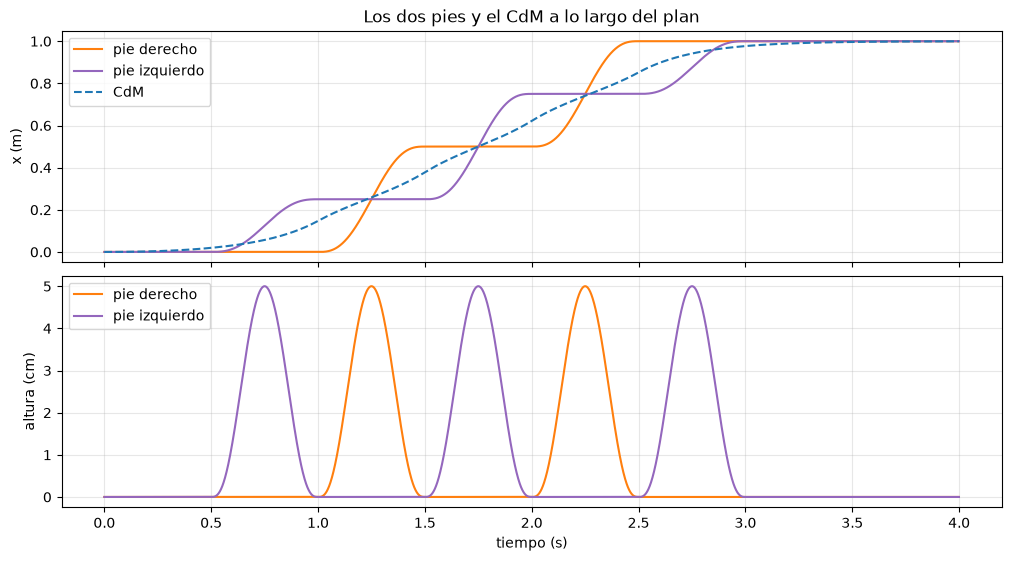

In [36]:
ALTURA_PASO = 0.05
fase = np.searchsorted(inicios, t, side="right") - 1
anteriores = np.vstack([[0.0, ANCHO / 2], pies[:-2]])
pie_d = np.zeros((len(t), 3))
pie_i = np.zeros((len(t), 3))
pie_d[:, :2] = pies[0]
pie_i[:, :2] = [0.0, ANCHO / 2]

for k in range(len(apoyos)):
    en_paso = fase == k + 1                               # la fase 0 es el arranque
    sigma = (t[en_paso] - inicios[k + 1]) / T
    vuela = pie_en_vuelo(anteriores[k], pies[k + 1], ALTURA_PASO, sigma)
    apoyado = np.append(apoyos[k], 0.0)
    if apoyos[k][1] < 0:                                  # apoyado el derecho: vuela el izquierdo
        pie_d[en_paso], pie_i[en_paso] = apoyado, vuela
    else:
        pie_i[en_paso], pie_d[en_paso] = apoyado, vuela
    despues = fase > k + 1                                # tras aterrizar, se queda en su pisada
    (pie_i if apoyos[k][1] < 0 else pie_d)[despues, :2] = pies[k + 1]

fig, ejes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True, layout="constrained")
for pie, nombre, color in [(pie_d, "derecho", "tab:orange"), (pie_i, "izquierdo", "tab:purple")]:
    ejes[0].plot(t, pie[:, 0], color=color, label=f"pie {nombre}")
    ejes[1].plot(t, pie[:, 2] * 100, color=color, label=f"pie {nombre}")
ejes[0].plot(t, X[:, 0], color="tab:blue", linestyle="--", label="CdM")
ejes[0].set(ylabel="x (m)", title="Los dos pies y el CdM a lo largo del plan")
ejes[1].set(ylabel="altura (cm)", xlabel="tiempo (s)")
for ax in ejes:
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left")
plt.show()

Varias técnicas de NumPy trabajando juntas:

- **`fase == k + 1`** es una máscara: los instantes del paso k. `pie_d[en_paso] = ...` asigna **solo** en esas filas (indexado con máscara, P6).
- **`pie_d[:, :2] = pies[0]`**: todas las filas, columnas x e y, con el mismo valor (broadcasting al asignar).
- **`(pie_i if ... else pie_d)[despues, :2] = ...`**: la expresión condicional (P1) elige **qué array** modificar, y luego se indexa. Compacto, pero no abuses: si cuesta leerlo, mejor un `if` normal.
- **`np.vstack`** pega en **vertical** (filas): la posición inicial del pie izquierdo encima de las pisadas.

La gráfica es una **escalera doble**: mientras un pie está quieto (apoyado), el otro sube por la curva quíntica; y el CdM (discontinuo) avanza entre los dos, siempre por en medio. Abajo, los "bultos" de 5 cm de cada pie en el aire, alternándose. El primer paso del pie derecho (de 1,0 a 1,5 s) es el **más largo** (de 0 a 0,5 m: los pies empezaban juntos) y el último del izquierdo, de 0,75 a 1,0, el más corto.

**Con esto, el plan está completo**: para cada milésima de segundo sabemos dónde tienen que estar el CdM y los dos pies. En el NB52 convertiremos eso en ángulos de cadera, rodilla y tobillo (cinemática inversa, NB46). Pero antes, una pregunta incómoda.


## 12 · ¿Y si lo seguimos al pie de la letra? Comprobación en MuJoCo

Un plan es una predicción hecha con un modelo. ¿Qué pasa al **ejecutarlo** en un mundo "de verdad"? Construyamos en MuJoCo el LIPM **literal**: una bola de 23,6 kg (la masa de Zancudo) que se puede mover en x, y, z, y una "pierna" sin masa que la une al ZMP. La pierna es una **fuerza** que aplicamos nosotros, en la dirección de la pierna (del pie al CdM), con el tamaño justo para que su parte vertical aguante el peso:

```
fuerza  =  m · g / z  ·  (CdM − pie)
```

Su parte vertical vale m · g / z · z = m · g (sostiene el peso: la bola no sube ni baja), y su parte horizontal, m · g / z · (x − p) = m · ω² · (x − p): exactamente el LIPM.

Para aplicar una fuerza desde fuera usamos **`datos.xfrc_applied`** (NB48): una tabla con una fila por cuerpo y 6 columnas (3 de fuerza y 3 de par), en coordenadas del mundo, que MuJoCo suma en cada paso.


In [37]:
LIPM_XML = f'''
<mujoco>
  <option timestep="0.001"/>
  <worldbody>
    <body name="cdm" pos="0 0 {z0}">
      <joint name="x" type="slide" axis="1 0 0"/>
      <joint name="y" type="slide" axis="0 1 0"/>
      <joint name="z" type="slide" axis="0 0 1"/>
      <geom type="sphere" size="0.05" mass="23.6"/>
    </body>
  </worldbody>
</mujoco>
'''
bola = mujoco.MjModel.from_xml_string(LIPM_XML)
d = mujoco.MjData(bola)
masa = bola.body_subtreemass[1]

def fuerza_pierna(d, zmp):
    cdm = np.array([d.qpos[0], d.qpos[1], z0 + d.qpos[2]])
    return masa * g / cdm[2] * (cdm - np.array([zmp[0], zmp[1], 0.0]))

print("masa:", masa, "kg")

masa: 23.6 kg


(El modelo usa una **f-string** con `{z0}` dentro del XML, P1: la bola empieza a la altura del CdM de Zancudo. Calculamos la posición del CdM directamente de `qpos`, la altura inicial más lo que se haya movido en z, porque `d.xpos` solo se actualiza **dentro** de `mj_step`, y cuando la leemos entre pasos va un pasito retrasada, NB45.)

Primera prueba: la caída de siempre (30 cm por detrás, a 1 m/s) durante 1 segundo, con los integradores de MuJoCo (NB49), frente a la fórmula exacta:


In [38]:
x_exacta, _ = lipm(-0.3, 1.0, 0.0, 1.0)
for nombre in ["EULER", "RK4"]:
    bola.opt.integrator = getattr(mujoco.mjtIntegrator, f"mjINT_{nombre}")
    mujoco.mj_resetData(bola, d)
    d.qpos[0], d.qvel[0] = -0.3, 1.0
    for _ in range(1000):
        d.xfrc_applied[1, :3] = fuerza_pierna(d, (0.0, 0.0))
        mujoco.mj_step(bola, d)
    print(f"{nombre:>5}: x = {d.qpos[0]:.4f}  (exacta {x_exacta:.4f}, error {abs(d.qpos[0] - x_exacta) * 1000:.1f} mm)   altura {z0 + d.qpos[2]:.4f}")
bola.opt.integrator = mujoco.mjtIntegrator.mjINT_EULER

EULER: x = -0.6556  (exacta -0.6441, error 11.5 mm)   altura 0.7100
  RK4: x = -0.6476  (exacta -0.6441, error 3.5 mm)   altura 0.7100


La altura se queda en 0,71 exacto (la fuerza de la pierna sostiene el peso), y la posición coincide con la fórmula... **casi**: 11,5 mm de error con Euler y 3,5 mm con RK4, en un solo segundo.

¿Por qué RK4 no es casi perfecto, si es de orden 4 (NB49)? Porque **nosotros** solo cambiamos la fuerza una vez por paso: durante cada milésima de segundo, la fuerza se queda **congelada**, aunque la bola se mueva. RK4 hace sus 4 evaluaciones con la misma fuerza vieja. Eso se llama un **retenedor de orden cero** (*zero-order hold*), y es lo que pasa con **cualquier** controlador de un robot real: calcula una orden, la manda, y la orden se queda fija hasta la siguiente. Es un error de **control**, no de integración. (Y, otra vez, el LIPM inestable lo amplifica.)

### Seguir el plan en bucle abierto

Ahora, lo de verdad: ejecutar **el plan de marcha** entero. En cada milésima, aplicamos la fuerza de la pierna con el ZMP que dice el plan, y miramos cuánto se separa la bola del CdM planificado. Dos casos: sin molestias, y con un **empujón** pequeño (le sumamos 0,2 m/s hacia delante a los 1,5 s, a mitad de la marcha).

Esto se llama ejecutar en **bucle abierto**: seguir las órdenes del plan **sin mirar** cómo va el robot (como andar con los ojos cerrados contando pasos).


In [39]:
def ejecutar(plan_zmp, empujon=0.0, ganancia=None):
    '''Sigue el plan con la bola. Si `ganancia` no es None, corrige el ZMP con el DCM medido.'''
    mujoco.mj_resetData(bola, d)
    cdm_real = np.zeros((len(plan_zmp), 2))
    zmp_usado = np.zeros((len(plan_zmp), 2))
    for i in range(len(plan_zmp)):
        if i == 1500:
            d.qvel[0] += empujon
        zmp = plan_zmp[i]
        if ganancia is not None:
            xi_medido = d.qpos[:2] + d.qvel[:2] / omega
            zmp = zmp + (1 + ganancia / omega) * (xi_medido - XI[i])
        d.xfrc_applied[1, :3] = fuerza_pierna(d, zmp)
        mujoco.mj_step(bola, d)
        cdm_real[i], zmp_usado[i] = d.qpos[:2], zmp
    return cdm_real, zmp_usado

for empujon in [0.0, 0.2]:
    cdm_real, _ = ejecutar(ZMP, empujon)
    error = np.linalg.norm(cdm_real - X, axis=1)
    print(f"bucle abierto, empujón {empujon} m/s: error al final {error[-1]:.3f} m")

bucle abierto, empujón 0.0 m/s: error al final 0.030 m
bucle abierto, empujón 0.2 m/s: error al final 292.114 m


**Sin ningún empujón**, siguiendo el plan al pie de la letra, la bola acaba a **3 cm** de donde debía, y alejándose. Solo por el pequeño error del retenedor y del integrador (los milímetros de la prueba anterior), multiplicado por la inestabilidad durante 4 segundos.

Y con un empujón de 0,2 m/s (más o menos un golpecito con un dedo), el error final es de casi **300 metros**: la bola sale disparada (y sería mucho más si el plan durase unos segundos más: cada 0,27 s, el error se multiplica por 2,718). En un robot de verdad, eso es caerse de bruces al medio segundo.

Esta es **la lección más importante de la parte de control**, y una pregunta de entrevista muy típica: **un plan de un sistema inestable no se puede seguir en bucle abierto**. Hace falta **realimentación**: medir cómo va el robot y corregir.

### Realimentación del DCM

¿Corregir qué y cómo? Aquí brilla lo del apartado 6: solo hay que controlar el **DCM**, y la herramienta es el **ZMP**. Llamemos **e** al error del DCM: e = ξ_medido − ξ_plan. Ya sabemos cómo se mueven los dos (velocidad = ω · (ξ − p)), así que el error se mueve así:

```
velocidad de e  =  ω · (e − (p − p_plan))
```

Si usamos exactamente el ZMP del plan (p = p_plan), queda velocidad de e = ω · e: el error **crece** exponencialmente. Lo que acabamos de ver. Pero si desplazamos el ZMP en proporción al error:

```
p  =  p_plan + (1 + k/ω) · e
```

entonces velocidad de e = ω · e − ω · (1 + k/ω) · e = **−k · e**: el error **se apaga**, dividiéndose entre 2,718 cada 1/k segundos. Hemos convertido la mitad inestable en estable, eligiendo nosotros la velocidad (k). Es el **controlador de seguimiento del DCM** (Englsberger 2015), una de las piezas básicas de los humanoides actuales. Es justo lo que hace la función `ejecutar` cuando le das una `ganancia`. Probemos con k = 3 por segundo:


In [40]:
resultados = {}
for nombre, empujon, ganancia in [("abierto, sin empujón", 0.0, None), ("abierto, con empujón", 0.2, None),
                                  ("DCM, sin empujón", 0.0, 3.0), ("DCM, con empujón", 0.2, 3.0)]:
    cdm_real, zmp_usado = ejecutar(ZMP, empujon, ganancia)
    resultados[nombre] = (cdm_real, zmp_usado)
    error = np.linalg.norm(cdm_real - X, axis=1)
    desvio_zmp = np.linalg.norm(zmp_usado - ZMP, axis=1).max()
    print(f"{nombre:>21}: error máximo {error.max() * 1000:12.1f} mm   al final {error[-1] * 1000:12.3f} mm"
          f"   el ZMP se aparta del plan hasta {desvio_zmp * 100:.1f} cm")

 abierto, sin empujón: error máximo         30.2 mm   al final       30.222 mm   el ZMP se aparta del plan hasta 0.0 cm


 abierto, con empujón: error máximo     292114.3 mm   al final   292114.312 mm   el ZMP se aparta del plan hasta 0.0 cm


     DCM, sin empujón: error máximo          0.8 mm   al final        0.064 mm   el ZMP se aparta del plan hasta 0.1 cm


     DCM, con empujón: error máximo         22.0 mm   al final        0.070 mm   el ZMP se aparta del plan hasta 9.7 cm


Con la realimentación del DCM:

- **Sin empujón**, el error máximo es de **0,8 mm** durante toda la marcha, y al final, 0,06 mm. Antes, 3 cm y creciendo.
- **Con empujón**, el CdM se aparta como mucho **2,2 cm** del plan, y vuelve a él: al final, 0,07 mm. Antes, cientos de metros.

El precio: para corregir el empujón, el ZMP se aparta del plan hasta **9,7 cm**. Y aquí está el límite de este controlador: el ZMP **tiene que estar dentro del pie** (NB39: el suelo solo puede empujar donde hay pie). Si el pie mide 20 cm, desde el centro hay 10 cm hasta la punta: este empujón cabe, **justo**. Uno un poco mayor no cabría, y entonces la única salida es **cambiar el plan**: dar el siguiente paso antes, o más largo (la capturabilidad del apartado 7). Eso es lo que hacen los controladores modernos más avanzados: **replanificar las pisadas** en cada instante.

Veámoslo en una gráfica. El error crece tan deprisa en bucle abierto que, en escala normal, las curvas buenas no se verían. Para eso existe la **escala logarítmica** (`ax.set_yscale("log")`, NB15b y NB49): cada raya del eje vertical es 10 veces la anterior, y una exponencial se ve como una **recta**:


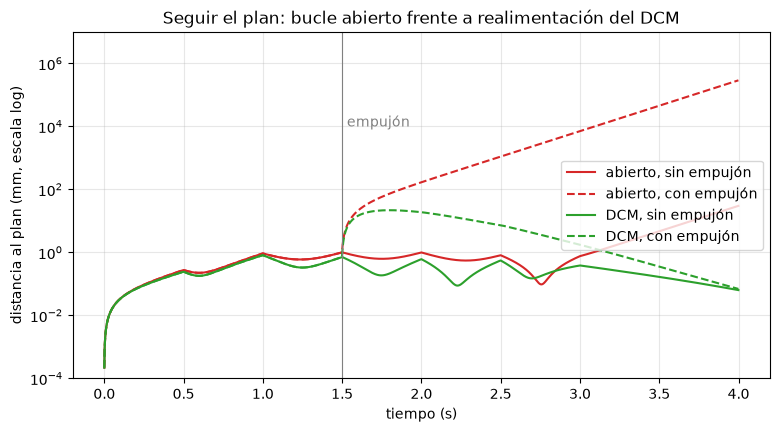

In [41]:
fig, ax = plt.subplots(figsize=(9, 4.5))
estilos = {"abierto, sin empujón": ("tab:red", "-"), "abierto, con empujón": ("tab:red", "--"),
           "DCM, sin empujón": ("tab:green", "-"), "DCM, con empujón": ("tab:green", "--")}
for nombre, (cdm_real, _) in resultados.items():
    color, linea = estilos[nombre]
    ax.plot(t, np.linalg.norm(cdm_real - X, axis=1) * 1000, color=color, linestyle=linea, label=nombre)
ax.axvline(1.5, color="gray", linewidth=0.8)
ax.text(1.53, 1e4, "empujón", color="gray")
ax.set_yscale("log")
ax.set(ylim=(1e-4, 1e7), xlabel="tiempo (s)", ylabel="distancia al plan (mm, escala log)",
       title="Seguir el plan: bucle abierto frente a realimentación del DCM")
ax.legend(loc="center right")
ax.grid(alpha=0.3, which="both")
plt.show()

En escala logarítmica, la historia salta a la vista:

- **Rojas** (bucle abierto): tras el empujón, una **recta que sube**: crecimiento exponencial, e^(ωt), el DCM huyendo. Sin empujón, sube igual, solo que empezando desde errores minúsculos.
- **Verdes** (DCM): el empujón dispara el error, que enseguida **baja en recta**: decrecimiento exponencial, e^(−kt), el controlador haciéndolo estable. Y sin empujón, se queda por debajo del milímetro todo el rato (los "dientes" son los cambios de pie, donde el ZMP del plan salta).

Todo esto con una **bola**. En el NB52, el mismo plan y el mismo controlador moverán a **Zancudo**, con sus piernas de verdad.


## 13 · Los límites del modelo (para no engañarse)

Lo que hemos hecho es la versión **de libro** de la planificación con LIPM. Funciona, pero tiene simplificaciones que hay que conocer (y que una entrevista te preguntará):

- **Sin apoyo doble**: en nuestro plan, el ZMP **salta** de un pie al otro en un instante. Al andar de verdad, hay un rato con **los dos pies** en el suelo, y el ZMP pasa de uno a otro **suavemente**. Un ZMP que salta exige fuerzas que cambian de golpe. En el NB52 lo arreglaremos con el **control por vista previa** (*preview control*) de Kajita, que genera un ZMP continuo.
- **El ZMP, un punto**: hemos puesto el ZMP en el centro de cada pie. En realidad puede moverse por toda la planta (de talón a punta), y aprovecharlo hace la marcha más natural y más larga.
- **Altura constante**: el CdM no sube ni baja. Los humanos sí lo hacemos (unos 4-5 cm por paso), y eso ahorra energía; los modelos que lo permiten son más complicados (no lineales).
- **Piernas sin masa**: la pierna en el aire pesa (en Zancudo, 5,8 kg de 23,6: un 25 %), y moverla empuja al resto del cuerpo. Ese error lo tiene que absorber la realimentación.
- **Sin giro del cuerpo**: el LIPM ignora el **momento angular** (los giros del torso, los brazos). Hay versiones más completas que lo incluyen.

Y aun así: Honda, Toyota, el HRP de Japón, Boston Dynamics en sus primeros robots... todos empezaron por aquí. Y muchos robots actuales entrenados con RL usan un plan de este tipo como **referencia** o como parte de la recompensa (lo veremos en el NB57).


## 14 · Resumen de la lección

1. **Exponencial** (repaso del NB15b y el NB17b): eᵗ es su propia pendiente; la de eᵃᵗ es a · eᵃᵗ. El número e ≈ 2,718.
2. **Solución del LIPM**: x(t) = p + (x₀ − p) · cosh(ωt) + (v₀/ω) · sinh(ωt). Exacta, sin el error de Euler (que es de orden 1, e inestable lo amplifica).
3. **DCM** (= punto de captura): ξ = x + v/ω. **Huye del pie** (velocidad ω · (ξ − p)); el **CdM lo persigue** (velocidad −ω · (x − ξ)). Controlar el DCM es controlar la parte inestable. El componente convergente es ζ = x − v/ω, y x = (ξ + ζ)/2.
4. **Energía orbital** = −ω² · (ξ − p) · (ζ − p): el producto de las dos mitades. Retrato de fase: punto de silla.
5. **Capturabilidad con N pasos**: d_N = r + (L + d_(N−1) − r) · e^(−ωΔt). Para Zancudo: 0,19 m/s solo con el tobillo, 0,61 con un paso, y nunca más de 0,82: cada paso ayuda un tercio de lo que ayudó el anterior.
6. **Marcha periódica**: v₀ = ω · (s/2) / tanh(ωT/2). Pasos cortos y rápidos = menos vaivén.
7. **Plan del DCM hacia atrás** (Englsberger): desde el final (parado), ξ_inicio = p + (ξ_fin − p) · e^(−ωT). Fase de arranque moviendo el ZMP entre los pies. CdM con fórmula exacta.
8. **Pie en el aire**: quíntico en horizontal (velocidad y aceleración cero en los extremos) y bulto 64σ³(1 − σ)³ en vertical.
9. **En MuJoCo**: el plan en **bucle abierto** diverge (3 cm sin molestias; cientos de metros con un empujón). Con **realimentación del DCM**, p = p_plan + (1 + k/ω) · (ξ − ξ_plan), se sigue al milímetro y aguanta el empujón, mientras el ZMP quepa en el pie.
10. **Python**: ufuncs y *duck typing*; vectorizar = sacar el bucle de Python (decenas de veces más rápido; para números sueltos, `math`); broadcasting con `np.newaxis`; máscaras, `argmax`, `np.where`; `meshgrid`, `cumsum`, `searchsorted`, `broadcast_to`, `hstack`/`vstack`/`column_stack`; `numpy.typing` (`NDArray`, `ArrayLike`). **matplotlib orientado a objetos**: `Figure`/`Axes`, funciones que reciben `ax`, `subplots` y `subplot_mosaic`, `layout="constrained"`, mapas de color con `Normalize` + `ScalarMappable` + `colorbar`, `pcolormesh`/`contour`, `bar`/`bar_label`, `annotate`, *patches*, `set_aspect("equal")`, escala logarítmica, `savefig` con dpi.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **cosh, sinh, tanh** | Coseno, seno y tangente hiperbólicos: combinaciones de eᵗ y e⁻ᵗ. |
| **Linealidad** | Si dos soluciones cumplen la ecuación, su suma también. |
| **DCM (ξ)** | *Divergent component of motion*: x + v/ω. Lo mismo que el punto de captura. |
| **Componente convergente (ζ)** | x − v/ω. Se acerca solo al pie. |
| **Retrato de fase** | Dibujo de la posición frente a la velocidad: cada punto es un estado. |
| **Punto de silla** | Equilibrio estable en una dirección e inestable en otra. |
| **Capturabilidad con N pasos** | Poder pararse dando N pasos o menos. |
| **Marcha periódica** | Andar con pasos que se repiten idénticos. |
| **Fase** | Trozo del plan con un mismo apoyo (arranque, cada paso, final). |
| **Bucle abierto / cerrado** | Seguir órdenes sin mirar / midiendo y corrigiendo (realimentación). |
| **Retenedor de orden cero** | Mantener una orden fija hasta la siguiente. |
| **Perfil quíntico** | 10σ³ − 15σ⁴ + 6σ⁵: de 0 a 1 con velocidad y aceleración cero en los extremos. |
| **ufunc** | Función de NumPy que trabaja elemento a elemento, en C. |
| ***Duck typing*** | Si se comporta como un número, sirve como número. |
| **Axes** | En matplotlib, UNA gráfica (no un eje). |
| **Mapa de color** | Función que convierte un número en un color. |
| **dpi** | Puntos por pulgada: la resolución de una figura guardada. |
| **Vectorial (pdf/svg)** | Formato de imagen que no se pixela al ampliar. |


## 15 · Preguntas de entrevista, con respuesta

**"Escribe la solución del LIPM. ¿Qué es ω?"**
x(t) = p + (x₀ − p) · cosh(ωt) + (v₀/ω) · sinh(ωt), con ω = √(g/z₀). ω es la "velocidad de caída": su inversa, 1/ω, es el tiempo en que la parte inestable se multiplica por e. Un robot más alto tiene ω menor y se cae más despacio.

**"¿Qué es el DCM y por qué se controla el DCM y no el CdM?"**
ξ = x + v/ω. La dinámica del LIPM se separa en dos sistemas de primer orden: el DCM, inestable (huye del ZMP), y el CdM, que converge solo hacia el DCM. Controlando el DCM con el ZMP, el CdM le sigue sin hacer nada. Es controlar solo la parte inestable, con un sistema de primer orden en vez de segundo.

**"¿Qué es la capturabilidad con N pasos?"**
El conjunto de estados desde los que el robot puede pararse con N pasos o menos, dados el tamaño del pie, el paso máximo y el tiempo mínimo de paso. Se calcula de forma recursiva; con el LIPM, las regiones son intervalos alrededor del pie que crecen con N pero se saturan, porque durante cada paso el DCM sigue huyendo.

**"¿Cómo generas la trayectoria del CdM a partir de las pisadas?"**
Con el DCM, hacia atrás: fijo el DCM final (parado, entre los pies), y para cada paso, del último al primero, ξ_inicio = p + (ξ_fin − p) · e^(−ωT). Luego integro el CdM hacia delante (persigue al DCM, con solución exacta). Alternativa clásica: control por vista previa del ZMP (Kajita 2003), NB52.

**"¿Qué propiedades debe tener la trayectoria del pie en el aire?"**
Empezar y acabar en las pisadas, con velocidad cero (sin arrastrar ni golpear) y, mejor, aceleración cero (sin tirones de par); altura suficiente para no tropezar. Típico: polinomio quíntico en horizontal, bulto polinómico o Bézier en vertical.

**"Si sigues un plan de LIPM en bucle abierto, ¿qué pasa?"**
Diverge: cualquier error (de modelo, de integración, un empujón) crece como e^(ωt). Hace falta realimentación, por ejemplo del DCM: p = p_plan + (1 + k/ω)(ξ − ξ_plan), que hace que el error decaiga como e^(−kt). Limitación: el ZMP tiene que quedar dentro del polígono de apoyo; si no cabe, hay que replanificar las pisadas.


## 16 · Ejercicios

**E1.** Comprueba, con pendientes numéricas, que `lipm` cumple de verdad la ecuación del LIPM: calcula la aceleración (la pendiente de la velocidad) en varios instantes y compárala con ω² · (x − p).

**E2.** Un robot está quieto, con el CdM sobre el centro del pie (x = 0), y recibe un empujón. Usando las cifras del apartado 7 (r = 5 cm, L = 35 cm, Δt = 0,3 s), escribe una función `pasos_necesarios(v)` que diga cuántos pasos necesita para un empujón de velocidad v (o `None` si no se puede parar). Pruébala con 0,1; 0,4; 0,7 y 0,9 m/s.

**E3.** ¿Qué ayuda más a la capturabilidad de Zancudo: una pierna un 20 % más **larga** (L = 0,42 m) o un 20 % más **rápida** (Δt = 0,24 s)? Calcula el empujón máximo con infinitos pasos en los dos casos.

**E4.** Deduce la fórmula de la marcha periódica: impón que el CdM, empezando en −s/2 con velocidad v₀ y el pie en 0, llegue a +s/2 al cabo de T segundos, y despeja v₀. Comprueba que (1 + cosh a)/sinh a = 1/tanh(a/2) con números.

**E5.** Comprueba que el perfil quíntico f(σ) = 10σ³ − 15σ⁴ + 6σ⁵ cumple f(0) = 0, f(1) = 1, y que su velocidad y su aceleración valen 0 en σ = 0 y σ = 1. Hazlo con las fórmulas de las pendientes de un polinomio (la de σⁿ es n · σⁿ⁻¹) y compruébalo con NumPy.

**E6.** Genera y dibuja un plan de marcha de **2 metros** con pasos de **0,4 m** y **T = 0,4 s**. ¿Cuál es la velocidad máxima del CdM hacia delante? ¿Y el alcance máximo de la pierna? ¿Sigue cabiendo en lo que da la pierna de Zancudo?

**E7.** **Reto.** Con la bola de MuJoCo y la realimentación del DCM (k = 3), busca el **empujón máximo** (a los 1,5 s, hacia delante) para el que el ZMP no se aparta del plan más de **10 cm** (la media longitud del pie). Usa una búsqueda binaria (NB48). ¿Cambia mucho si usas k = 6? ¿Por qué crees que pasa?


<details>
<summary>▶ Solución E1</summary>

```python
tt = np.linspace(0.0, 1.0, 10001)        # otro nombre, para no pisar la `t` del plan
x, v = lipm(-0.3, 1.0, 0.0, tt)
aceleracion = np.gradient(v, tt)
print(np.abs(aceleracion - omega ** 2 * x)[1:-1].max())     # ≈ 2e-7
```

La diferencia máxima es de unas dos diezmillonésimas (lo que se equivoca `np.gradient` con puntos separados 0,0001 s). (Usamos `tt` y no `t` porque `t` guarda los instantes del plan de marcha, y la función `ejecutar` de la sección 12 la necesita: pisar variables globales es una fuente clásica de errores en los notebooks.) La fórmula cumple la ecuación. Quitamos el primer y el último punto (`[1:-1]`) porque en los bordes `np.gradient` usa una pendiente menos precisa.
</details>

<details>
<summary>▶ Solución E2</summary>

```python
def pasos_necesarios(v, r=0.05, L=0.35, dt_paso=0.3, maximo=20):
    distancia = v / omega                      # el DCM, con el CdM sobre el pie
    encoge = math.exp(-omega * dt_paso)
    d = r
    for n in range(maximo + 1):
        if distancia <= d:
            return n
        d = r + (L + d - r) * encoge
    return None

for v in [0.1, 0.4, 0.7, 0.9]:
    print(v, pasos_necesarios(v))
```

0,1 m/s → **0 pasos** (basta el tobillo); 0,4 → **1**; 0,7 → **2**; 0,9 → **None**: por encima de 0,82 no hay número de pasos que valga. El bucle tiene un `maximo` de seguridad para no dar vueltas para siempre buscando lo imposible (d se acerca al límite sin pasarlo nunca).
</details>

<details>
<summary>▶ Solución E3</summary>

```python
def empujon_maximo(r=0.05, L=0.35, dt_paso=0.3):
    encoge = math.exp(-omega * dt_paso)
    return omega * (r + L * encoge / (1 - encoge))

print("normal:      ", round(empujon_maximo(), 3))
print("más larga:   ", round(empujon_maximo(L=0.42), 3))
print("más rápida:  ", round(empujon_maximo(dt_paso=0.24), 3))
```

Normal **0,82**; pierna más larga **0,95**; pierna más rápida **1,09** m/s. Gana con claridad la **rapidez**: el tiempo está dentro de una exponencial, y cada décima de segundo que el pie tarda en llegar, el DCM se escapa multiplicando. Por eso los robots que se recuperan bien de empujones (y las personas) dan pasos **rápidos**, no necesariamente largos. Y por eso en robótica se pelea tanto por motores con buena velocidad, no solo con mucha fuerza.
</details>

<details>
<summary>▶ Solución E4</summary>

Con p = 0, x₀ = −s/2: x(T) = −(s/2) · cosh(ωT) + (v₀/ω) · sinh(ωT) = s/2. Despejando:

```
v₀ = ω · (s/2) · (1 + cosh(ωT)) / sinh(ωT)
```

Y por simetría, la velocidad al final también es v₀ (puedes comprobarlo con `lipm`). La identidad:

```python
for a in [0.5, 1.0, 2.0]:
    print((1 + math.cosh(a)) / math.sinh(a), 1 / math.tanh(a / 2))
```

Dan lo mismo. (Se demuestra escribiendo cosh y sinh con exponenciales y simplificando, si te apetece un rato con lápiz.)
</details>

<details>
<summary>▶ Solución E5</summary>

Con la regla de σⁿ → n · σⁿ⁻¹:

- f(σ) = 10σ³ − 15σ⁴ + 6σ⁵ → f(0) = 0, f(1) = 10 − 15 + 6 = **1** ✓
- velocidad: 30σ² − 60σ³ + 30σ⁴ = 30σ²(1 − σ)² → **0** en σ = 0 y en σ = 1 ✓
- aceleración: 60σ − 180σ² + 120σ³ = 60σ(1 − σ)(1 − 2σ) → **0** en σ = 0 y σ = 1 ✓

```python
s = np.array([0.0, 1.0])
print(quintico(s))                                         # [0. 1.]
print(30 * s**2 - 60 * s**3 + 30 * s**4)                   # [0. 0.]
print(60 * s - 180 * s**2 + 120 * s**3)                    # [0. 0.]
```

Fíjate en la velocidad factorizada, 30σ²(1 − σ)²: es siempre positiva (el pie nunca va hacia atrás) y máxima en σ = 0,5, donde vale 30/16 = 1,875: a mitad de camino, el pie va casi al doble de la velocidad media.
</details>

<details>
<summary>▶ Solución E6</summary>

```python
pies2 = plan_pies(2.0, 0.4, ANCHO)
T = 0.4
apoyos2, final2 = pies2[:-1], (pies2[-1] + pies2[-2]) / 2
xi_ini2 = np.empty_like(apoyos2)
siguiente = final2
for k in range(len(apoyos2) - 1, -1, -1):
    xi_ini2[k] = apoyos2[k] + (siguiente - apoyos2[k]) * math.exp(-omega * T)
    siguiente = xi_ini2[k]
zmp0 = -xi_ini2[0] / (math.exp(omega * T0) - 1)
fases2 = ([Fase(zmp0, T0, np.zeros(2))] + [Fase(apoyos2[k], T, xi_ini2[k]) for k in range(len(apoyos2))]
          + [Fase(final2, 1.0, final2)])
t2, X2, XI2, ZMP2 = trayectoria_cdm(fases2)

vel2 = np.gradient(X2, t2, axis=0)
print("velocidad máxima:", vel2[:, 0].max().round(3))
print("alcance máximo:", np.linalg.norm(X2 - ZMP2, axis=1).max().round(3))

fig, ax = plt.subplots(figsize=(11, 3))
dibujar_pies(ax, pies2)
ax.plot(X2[:, 0], X2[:, 1], linewidth=2, label="CdM")
ax.plot(XI2[:, 0], XI2[:, 1], label="DCM")
ax.set_aspect("equal")
ax.legend()
plt.show()
```

La velocidad máxima sube a **1,155 m/s** y el alcance máximo a **0,274 m**: pasos más largos y más rápidos. Todavía cabe en los 0,387 m de la pierna de Zancudo, pero con menos margen. (¡Ojo! Esta T = 0,4 cambia la variable global `T` del notebook; si vuelves a ejecutar celdas de arriba, ponla otra vez a 0,5.)
</details>

<details>
<summary>▶ Solución E7</summary>

```python
def desvio_maximo(empujon, k=3.0):
    _, zmp_usado = ejecutar(ZMP, empujon, k)
    return np.linalg.norm(zmp_usado - ZMP, axis=1).max()

for k in [3.0, 6.0]:
    cabe, no_cabe = 0.0, 1.0
    for _ in range(20):
        medio = (cabe + no_cabe) / 2
        if desvio_maximo(medio, k) <= 0.10:
            cabe = medio
        else:
            no_cabe = medio
    print(f"k = {k}: empujón máximo ≈ {cabe:.3f} m/s")
```

Con k = 3, unos **0,21 m/s**; con k = 6, **menos**, unos 0,14. Parece contradictorio (una corrección más fuerte debería ayudar), pero tiene sentido: con k grande, el controlador corrige **más deprisa**, y para eso tiene que mover el ZMP **más lejos** de golpe, (1 + k/ω) veces el error. Con el ZMP limitado por el tamaño del pie, una corrección suave aprovecha mejor el poco margen que hay. Es un ejemplo de algo muy general en control: **más ganancia no siempre es mejor** cuando las acciones están limitadas (en el NB40 lo vimos con el PD y los límites de par).

Y comparado con la capturabilidad (apartado 7: 0,19 m/s sin pasos), 0,21 m/s está muy cerca: los dos cálculos dicen lo mismo, "con el tobillo solo se aguantan golpecitos". Para más, hay que dar pasos.
</details>


## 17 · 🛠 Práctica en MuJoCo: ¿obedece Zancudo al DCM?

Toda la lección se ha apoyado en una idea: **el DCM decide**. Si el DCM (ξ = x + v/ω) se queda dentro del pie, el tobillo puede frenar la caída sin dar ningún paso; si se sale, ya no hay tobillo que valga: o das un paso o te caes. Lo hemos comprobado con una **bola**, que es un LIPM perfecto por construcción.

Pero Zancudo **no** es una bola: tiene piernas con masa, su centro de masas sube y baja, sus motores son muelles que ceden, y sus pies son cápsulas que pueden rodar. ¿Sigue valiendo la regla? Es la pregunta que se hace cualquier ingeniero antes de fiarse de un modelo simplificado: **¿cuánto se parece el robot de verdad al modelo?**

En la práctica del NB45 montaste un banco de empujones y encontraste **dónde** está el umbral de caída de Zancudo. Hoy vas a ver **por qué** está ahí. El plan:

1. Dejar a Zancudo v2 asentado en la postura `agachado` y guardar ese estado.
2. Medir **su** ω y **sus** bordes del pie (no los "digamos 5 cm" del apartado 7).
3. Darle empujones cortos y seguir su DCM en cada paso de la simulación.
4. Buscar el empujón más fuerte que aguanta, hacia delante y hacia atrás, y mirar **dónde llegó su DCM**.
5. Verlo en una gráfica y en un vídeo.


### Paso 1 · Zancudo asentado

Empezamos desde el keyframe `agachado` y dejamos que pase 1 segundo para que los motores-muelle se asienten (NB50: bajan un poco bajo el peso). Ese estado será el punto de partida de **todos** los empujones: lo copiamos con `mj_copyData` (NB45), así cada prueba empieza exactamente igual.


In [42]:
z_v2 = mujoco.MjModel.from_xml_path("robots/zancudo_v2.xml")
asentado = mujoco.MjData(z_v2)
mujoco.mj_resetDataKeyframe(z_v2, asentado, z_v2.key("agachado").id)
for paso in range(500):                                  # 1 segundo
    mujoco.mj_step(z_v2, asentado)
mujoco.mj_forward(z_v2, asentado)

TORSO, PIE = z_v2.body("torso").id, z_v2.body("pie_d").id
z_cdm = asentado.subtree_com[TORSO][2]
omega_z = np.sqrt(g / z_cdm)
x_cdm = asentado.subtree_com[TORSO][0] - asentado.xpos[PIE][0]       # CdM respecto al tobillo
print(f"altura del CdM: {z_cdm:.3f} m  →  ω = {omega_z:.3f} 1/s")
print(f"el CdM está {100 * x_cdm:.1f} cm por delante del tobillo")

altura del CdM: 0.698 m  →  ω = 3.750 1/s
el CdM está 2.9 cm por delante del tobillo


### Paso 2 · Los bordes del pie

¿Dónde están la punta y el talón? El pie de Zancudo es una **cápsula** tumbada: un segmento con media esfera en cada punta. Sobre un suelo plano, toca el suelo por la línea de abajo del segmento, así que los puntos de apoyo extremos son los **extremos del segmento** (no los de las semiesferas). El modelo guarda el centro de la forma (`geom_pos`, respecto al tobillo) y su media longitud (`geom_size[1]`):


In [43]:
forma_pie = z_v2.geom("pie_d")
centro, media = forma_pie.pos[0], forma_pie.size[1]
PUNTA, TALON = centro + media, centro - media
print(f"centro del pie: {100 * centro:.0f} cm por delante del tobillo; media longitud {100 * media:.0f} cm")
print(f"punta: {100 * PUNTA:+.0f} cm   talón: {100 * TALON:+.0f} cm")
print(f"margen del DCM al empezar: {100 * (PUNTA - x_cdm):.1f} cm hacia delante, {100 * (x_cdm - TALON):.1f} cm hacia atrás")

centro del pie: 4 cm por delante del tobillo; media longitud 10 cm
punta: +14 cm   talón: -6 cm
margen del DCM al empezar: 11.1 cm hacia delante, 8.9 cm hacia atrás


(Funciona porque la cápsula está girada para quedar tumbada a lo largo de x: su `pos` es el centro del segmento en el marco del pie, y en la postura `agachado` el pie está plano, así que el marco del pie y el del tobillo coinciden en x. Si el pie estuviera inclinado, habría que usar `geom_xpos` y `geom_xmat`, NB46.)

Así que Zancudo tiene mucho más pie que los 5 cm que supusimos en el apartado 7: **11 cm** de margen hacia delante y **9 cm** hacia atrás.

### Paso 3 · Empujar y seguir el DCM

La función `empujon` copia el estado asentado, empuja el torso con una fuerza horizontal F durante `duracion` segundos (con `xfrc_applied`, como en el apartado 12) y, en cada paso, calcula el DCM **del robot entero**: la posición y la velocidad del centro de masas de todo el árbol que cuelga del torso.

- La posición del CdM ya la teníamos: `subtree_com`.
- Su velocidad está en **`subtree_linvel`**, pero MuJoCo no la calcula en cada paso (cuesta tiempo y casi nunca hace falta). Hay que pedírsela con **`mujoco.mj_subtreeVel(modelo, datos)`**, otra de esas funciones "de una pieza" del NB45.

Devuelve si se ha caído (el torso pasa de 0,3 rad, como en el NB50) y la trayectoria del DCM respecto al tobillo, como array de NumPy:


In [44]:
def empujon(fuerza: float, duracion: float = 0.1, segundos: float = 4.0) -> tuple[bool, np.ndarray]:
    dz = mujoco.MjData(z_v2)
    mujoco.mj_copyData(dz, z_v2, asentado)
    inicio = dz.time
    dcm = []
    for paso in range(int(round(segundos / z_v2.opt.timestep))):
        dz.xfrc_applied[TORSO, 0] = fuerza if dz.time - inicio < duracion else 0.0
        mujoco.mj_step(z_v2, dz)
        mujoco.mj_subtreeVel(z_v2, dz)
        dcm.append(dz.subtree_com[TORSO][0] + dz.subtree_linvel[TORSO][0] / omega_z - dz.xpos[PIE][0])
        if abs(dz.qpos[2]) > 0.3:
            return True, np.array(dcm)
    return False, np.array(dcm)

for fuerza in [40, 100, -40, -100]:
    cae, dcm = empujon(fuerza)
    print(f"empujón de {fuerza:+4d} N durante 0,1 s: {'SE CAE ' if cae else 'aguanta'}   "
          f"DCM entre {100 * dcm.min():+.1f} y {100 * dcm.max():+.1f} cm")

empujón de  +40 N durante 0,1 s: aguanta   DCM entre +0.6 y +8.8 cm
empujón de +100 N durante 0,1 s: SE CAE    DCM entre +3.4 y +36.6 cm
empujón de  -40 N durante 0,1 s: aguanta   DCM entre -1.6 y +5.4 cm
empujón de -100 N durante 0,1 s: SE CAE    DCM entre -22.9 y +3.4 cm


Con 40 N, el DCM se mueve unos centímetros, se queda **dentro** del pie y Zancudo aguanta. Con 100 N, el DCM llega **más allá de la punta** (o del talón) y Zancudo se cae. Hasta aquí, lo esperado. La pregunta fina es **dónde está la frontera**.

### Paso 4 · La frontera, con búsqueda binaria

Buscamos el empujón más fuerte que aguanta en cada sentido (12 vueltas de búsqueda binaria, como en el NB50) y miramos hasta dónde llegó el DCM en ese caso límite:


In [45]:
def empujon_maximo(sentido: int) -> float:
    aguanta, cae = 0.0, 400.0
    for vuelta in range(12):
        medio = (aguanta + cae) / 2
        if empujon(sentido * medio)[0]:
            cae = medio
        else:
            aguanta = medio
    return aguanta

limites = {}
for sentido, nombre, borde in [(+1, "delante", PUNTA), (-1, "detrás", TALON)]:
    fuerza = empujon_maximo(sentido)
    _, dcm = empujon(sentido * fuerza)
    extremo = dcm.max() if sentido > 0 else dcm.min()
    limites[nombre] = sentido * fuerza
    print(f"hacia {nombre:>7}: aguanta hasta {fuerza:5.1f} N · 0,1 s;  su DCM llegó a {100 * extremo:+.1f} cm;  "
          f"el borde del pie está en {100 * borde:+.0f} cm")

hacia delante: aguanta hasta  70.2 N · 0,1 s;  su DCM llegó a +13.5 cm;  el borde del pie está en +14 cm


hacia  detrás: aguanta hasta  66.9 N · 0,1 s;  su DCM llegó a -5.6 cm;  el borde del pie está en -6 cm


**Zancudo obedece al DCM, al milímetro.** En el empujón más fuerte que aguanta hacia delante (unos 70 N durante 0,1 s), su DCM llega a **13,5 cm**, y la punta está a 14. Hacia atrás (unos 67 N), llega a **−5,6 cm**, y el talón está a −6. Medio centímetro de diferencia, con un robot de 9 articulaciones, piernas pesadas y motores que ceden.

Es un resultado importante: el LIPM, que parecía una simplificación de pizarra, describe **exactamente** la frontera entre caerse y no caerse de un robot "de verdad", cuando se mide con el DCM del robot completo. Por eso los humanoides reales controlan el DCM.

(¿Por qué las fuerzas límite se parecen tanto, 70 y 67 N, si el margen delante es de 11 cm y detrás de 9? Porque la fuerza no se traduce en DCM de forma sencilla: durante el propio empujón, el suelo también empuja, y lo hace distinto según el sentido. Lo verás en el R1. Lo que **no** depende de esos detalles es la frontera: el borde del pie.)

(Si comparas con el NB45, allí el umbral salía en 77 N: aquel banco partía de otro estado y daba por caído al robot cuando el torso bajaba de 0,5 m en 2 s. El umbral exacto depende del criterio; la frontera del DCM, no.)

### Paso 5 · Verlo

La gráfica clave: el DCM frente al tiempo, en los dos casos límite de cada lado (el que aguanta y uno un 5 % más fuerte), con los bordes del pie como líneas. Usamos la interfaz orientada a objetos de matplotlib del apartado 5:


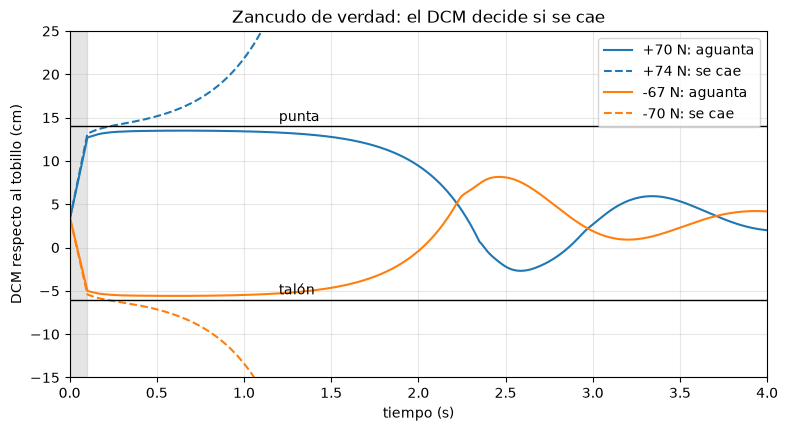

In [46]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for nombre, color in [("delante", "tab:blue"), ("detrás", "tab:orange")]:
    for factor, linea in [(1.0, "-"), (1.05, "--")]:
        cae, dcm = empujon(limites[nombre] * factor)
        tiempo = np.arange(1, len(dcm) + 1) * z_v2.opt.timestep
        etiqueta = f"{limites[nombre] * factor:+.0f} N: {'se cae' if cae else 'aguanta'}"
        ax.plot(tiempo, 100 * dcm, color=color, linestyle=linea, label=etiqueta)
for borde, texto in [(PUNTA, "punta"), (TALON, "talón")]:
    ax.axhline(100 * borde, color="k", linewidth=1)
    ax.text(1.2, 100 * borde + 0.6, texto)
ax.axvspan(0, 0.1, color="gray", alpha=0.2)
ax.set(xlim=(0, 4), ylim=(-15, 25), xlabel="tiempo (s)", ylabel="DCM respecto al tobillo (cm)",
       title="Zancudo de verdad: el DCM decide si se cae")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.show()

La franja gris es el empujón. Las líneas continuas (aguanta) llegan **justo** al borde del pie y se quedan ahí, pegadas, casi un segundo y medio (Zancudo haciendo equilibrio sobre la punta o el talón, como un lápiz casi vertical), hasta que vuelven; las discontinuas (un 5 % más) lo **cruzan** y se disparan: esa es la mitad divergente del apartado 6, en un robot entero. Una frontera nítida, justo donde dice la teoría.

Y el vídeo del caso que se cae hacia delante (empujón un 5 % por encima del límite). Fíjate en el momento en que el talón se despega: es cuando el DCM cruza la punta. `taller.video` necesita una función de control que empuje durante la primera décima:


In [47]:
import taller

d_video = mujoco.MjData(z_v2)
mujoco.mj_copyData(d_video, z_v2, asentado)
inicio_video = d_video.time

def golpe(modelo, datos):
    datos.xfrc_applied[TORSO, 0] = 1.05 * limites["delante"] if datos.time - inicio_video < 0.1 else 0.0

fotos = taller.video(z_v2, d_video, segundos=3, control=golpe, nombre="nb51_dcm_se_cae")

### Tus retos

**R1.** El empujón límite hacia delante es de unos 70 N durante 0,1 s: un **impulso** F·Δt = 7 N·s (en la práctica del NB45 viste que, en golpes cortos, lo que cuenta es el impulso). Predícelo con el LIPM: el DCM empieza en x₀ y, tras un golpe instantáneo que da a **todo** el robot una velocidad Δv = impulso / masa, pasa a x₀ + Δv/ω. ¿Qué impulso lo deja justo en la punta? Compruébalo con un golpe de 0,01 s. ¿Coincide? ¿Por qué no?

**R2.** Con `MjSpec` (NB50), alarga la **puntera** de los dos pies 5 cm (la media longitud de la cápsula de 0,10 a 0,125 m, y su centro de 0,04 a 0,065, para que el talón no cambie). Repite la búsqueda hacia delante. ¿Hasta dónde llega ahora el DCM en el caso límite?

**R3.** En el apartado 7 supusimos r = 5 cm y salía que Zancudo aguanta, solo con el tobillo, 0,19 m/s. Con los márgenes **medidos** hoy, ¿qué velocidad máxima predice la fórmula ξ = x + v/ω ≤ punta, partiendo del CdM asentado?


<details>
<summary>▶ Solución R1</summary>

```python
masa_z = z_v2.body_subtreemass[TORSO]
print("predicción LIPM:", masa_z * omega_z * (PUNTA - x_cdm), "N·s")

aguanta, cae = 0.0, 3000.0
for vuelta in range(14):
    medio = (aguanta + cae) / 2
    if empujon(medio, duracion=0.01)[0]:
        cae = medio
    else:
        aguanta = medio
print(f"medido con Δt = 0,01 s: F máx = {aguanta:.0f} N, impulso = {aguanta * 0.01:.2f} N·s")
```

La predicción da 23,6 · 3,75 · 0,111 ≈ **9,8 N·s**. Lo medido: unos 699 N durante 0,01 s, **7,0 N·s** (el mismo impulso que con 70 N durante 0,1 s). La predicción se pasa un 40 %.

¿Por qué falla? Porque supone que el golpe da su velocidad a **todo** el robot. Pero empujamos el **torso**, a casi 1 metro del suelo, y los pies están sujetos por el rozamiento: el robot no se traslada entero, **gira** alrededor de los pies, y el suelo devuelve parte del golpe con una fuerza de rozamiento hacia atrás. El CdM recibe menos velocidad que impulso / masa. La regla del DCM sigue valiendo (lo has visto en el paso 4: la frontera está en la punta); lo que falla es el cálculo de **cuánto mueve un golpe el DCM**, que depende de dónde y cómo se empuja.
</details>

<details>
<summary>▶ Solución R2</summary>

```python
spec_pie = mujoco.MjSpec.from_file("robots/zancudo_v2.xml")
for lado in ["d", "i"]:
    forma = spec_pie.geom(f"pie_{lado}")
    forma.size[1], forma.pos[0] = 0.125, 0.065
z_v2 = spec_pie.compile()                     # empujon() y empujon_maximo() usan z_v2: lo cambiamos...
asentado = mujoco.MjData(z_v2)                # ...y volvemos a asentarlo
mujoco.mj_resetDataKeyframe(z_v2, asentado, z_v2.key("agachado").id)
for paso in range(500):
    mujoco.mj_step(z_v2, asentado)
mujoco.mj_forward(z_v2, asentado)

fuerza = empujon_maximo(+1)
print(fuerza, empujon(fuerza)[1].max())
```

Ahora aguanta **104 N** (antes 70: un 49 % más con un pie un 25 % más largo) y, en el caso límite, el DCM llega a **18,2 cm**, con la punta en 19. La frontera se ha movido **con el pie**: otra confirmación de la regla.

(Ojo: este código cambia las variables globales `z_v2` y `asentado`. Si después quieres volver al Zancudo normal, vuelve a ejecutar el paso 1. Es el problema de las funciones que leen variables globales, NB23: en una librería, `empujon` recibiría el modelo y el estado como argumentos.)
</details>

<details>
<summary>▶ Solución R3</summary>

ξ = x + v/ω ≤ punta  →  v ≤ ω · (punta − x) = 3,75 · (0,14 − 0,029) ≈ **0,42 m/s** hacia delante, y 3,75 · (0,029 + 0,06) ≈ **0,33 m/s** hacia atrás.

Con los pies de verdad de Zancudo, el tobillo solo frena el **doble** de lo que suponíamos con r = 5 cm (0,19 m/s). Sigue siendo poco: un empujón como el de alguien que tropieza contigo por la calle es de 0,5-1 m/s. Para eso, como dice la lección, hay que **dar pasos**.
</details>


### Qué has aprendido de MuJoCo hoy

- **Medir el DCM de un robot entero**: `subtree_com` (posición) y `subtree_linvel` (velocidad, que hay que pedir con **`mj_subtreeVel`**), con el ω de su altura real.
- **Leer la geometría del modelo** para sacar números físicos: los extremos del pie salen de `geom_pos` y `geom_size` de la cápsula.
- **Partir siempre del mismo estado** con `mj_copyData`: un estado asentado como "punto de partida" de muchos experimentos.
- **Golpes con `xfrc_applied` y búsqueda binaria de la frontera**, y que un golpe en el torso mueve el DCM menos de lo que diría impulso / masa: el suelo también empuja.
- **El veredicto**: el robot completo, con piernas, motores blandos y pies de cápsula, se cae justo cuando su DCM cruza el borde del pie. El LIPM no es solo de pizarra.

En la práctica del **NB52** usarás la librería `andar` para algo que el notebook no hace: medir **cuánto retraso** de los motores aguanta la marcha clásica antes de caerse.


## 18 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

En el **NB52**, Zancudo andará **sin RL**: el control por vista previa del ZMP de Kajita (un ZMP continuo, con apoyo doble), la **cinemática inversa** (NB46) para convertir el plan del CdM y los pies en ángulos de cadera, rodilla y tobillo, y el PD de los motores para seguirlos. Y al final, la comparación honesta: control clásico frente a RL. En Python: cómo diseñar una **pequeña librería** (módulos, interfaz pública, `__init__.py`) y el módulo **`logging`**, la forma profesional de dejar rastro de lo que hace un programa.
